# Mini-project: Applying supervised learning to predict student dropout

**Welcome to your Mini-project: Applying supervised learning to predict student dropout rate**

In this project, we will examine student data and use supervised learning techniques to predict whether a student will drop out. In the education sector, retaining students is vital for the institution's financial stability and for students’ academic success and personal development. A high dropout rate can lead to significant revenue loss, diminished institutional reputation, and lower overall student satisfaction.

You will work with the data in three distinct stages:

1.  Applicant and course information
2.  Student and engagement data
3.  Academic performance data

These stages reflect Study Group’s real-world data journey and how student information has progressed and become available. Additionally, this approach enables you, through data exploration, to support Study Group in better understanding and identifying key metrics to monitor. This approach will also assist you in determining at which stage of the student journey interventions would be most effective.

Please set aside approximately **12 hours** to complete the mini-project.

## Business context
Study Group specialises in providing educational services and resources to students and professionals across various fields. The company's primary focus is on enhancing learning experiences through a range of services, including online courses, tutoring, and educational consulting. By leveraging cutting-edge technology and a team of experienced educators, Study Group aims to bridge the gap between traditional learning methods and the evolving needs of today's learners.

Study Group serves its university partners by establishing strategic partnerships to enhance the universities’ global reach and diversity. It supports the universities in their efforts to attract international students, thereby enriching the cultural and academic landscape of their campuses. It works closely with university faculty and staff to ensure that the universities are prepared and equipped to welcome and support a growing international student body. Its partnership with universities also offers international students a seamless transition into their chosen academic environment.

Study Group runs several International Study Centres across the UK and Dublin in partnership with universities with the aim of preparing a pipeline of talented international students from diverse backgrounds for degree study. These centres help international students adapt to the academic, cultural, and social aspects of studying abroad. This is achieved by improving conversational and subject-specific language skills and academic readiness before students progress to a full degree programme at university.

Through its comprehensive suite of services, it supports learners and universities at every stage of their educational journey, from high school to postgraduate studies. Its approach is tailored to meet the unique needs of each learner, offering personalised learning paths and flexible scheduling options to accommodate various learning styles and commitments.

Study Group's services are designed to be accessible and affordable, making quality education a reality for many individuals. By focusing on the integration of technology and personalised learning, the company aims to empower learners to achieve their full potential and succeed in their academic and professional pursuits. Study Group is at the forefront of transforming how people learn and grow through its dedication to innovation and excellence.

Study Group has provided you with 3 data sets.


## Objective
By the end of this mini-project, you will have developed the skills and knowledge to apply advanced machine learning techniques to create a predictive model for student dropout. This project will involve comprehensive data exploration, preprocessing, and feature engineering to ensure high-quality input for the models. You will employ and compare multiple predictive algorithms, such as XGBoost, and a neural network-based model, to determine the most effective model for predicting student dropout.

In the Notebook, you will:
- explore the data sets, taking a phased approach
- preprocess the data and conduct feature engineering
- predict the dropout rate using XGBoost, and a neural network-based model.

You will also write a report summarising the results of your findings and recommendations.

## Assessment criteria
By completing this project, you’ll be able to provide evidence that you can:

- develop accurate predictions across diverse organisational scenarios by building and testing advanced ML models
- inform data-driven decision-making with advanced machine learning algorithms and models
- propose and present effective solutions to organisational problems using data preprocessing, model selection, and insightful analysis techniques.



# Import the necessary libraries

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from xgboost import XGBClassifier
from collections import Counter

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical
import tensorflow as tf
!pip install scikeras
from scikeras.wrappers import KerasClassifier

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
!pip install scikit-learn==1.4.2


import warnings
warnings.filterwarnings("ignore")

# Stage 1 data

# Load and view data set

In [ ]:
# Define the File URL variable
file_url = "https://drive.google.com/uc?id=1pA8DDYmQuaLyxADCOZe1QaSQwF16q1J6"

# Load data set
data_1 = pd.read_csv(file_url)
data_1.head()

,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen


**Stage 1: Pre-processing instructions**
- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with > 50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.

# Data Pre-processing & EDA

In [ ]:
# View meta data
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CentreName             25059 non-null  object
 1   LearnerCode            25059 non-null  int64 
 2   BookingType            25059 non-null  object
 3   LeadSource             25059 non-null  object
 4   DiscountType           7595 non-null   object
 5   DateofBirth            25059 non-null  object
 6   Gender                 25059 non-null  object
 7   Nationality            25059 non-null  object
 8   HomeState              8925 non-null   object
 9   HomeCity               21611 non-null  object
 10  CourseLevel            25059 non-null  object
 11  CourseName             25059 non-null  object
 12  IsFirstIntake          25059 non-null  bool  
 13  CompletedCourse        25059 non-null  object
 14  ProgressionDegree      24184 non-null  object
 15  ProgressionUniversi

In [ ]:
# Convert DateofBirth to Datetime and Calculate Age
data_1['DateofBirth'] = pd.to_datetime(data_1['DateofBirth'], dayfirst=True
                                       , errors='coerce')
current_date = pd.to_datetime('today')

data_1['Age'] = current_date.year - data_1['DateofBirth'].dt.year

print(f"List of Updated Columns:", data_1.columns.tolist())
print(f'Updated Shape:',data_1.shape)

List of Updated Columns: ['CentreName', 'LearnerCode', 'BookingType', 'LeadSource', 'DiscountType', 'DateofBirth', 'Gender', 'Nationality', 'HomeState', 'HomeCity', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionDegree', 'ProgressionUniversity', 'Age']
Updated Shape: (25059, 17)


In [ ]:
# Check for duplicate values
data_1.duplicated().sum()

np.int64(0)

In [ ]:
# Remove Columns not relevant for analysis (LearnerCode and DateofBirth)
data_1.drop(columns=['LearnerCode', 'DateofBirth'], inplace=True)

print(f'Updated Column list: {data_1.columns.tolist()}')
print(f'Updated data shape:', data_1.shape)

Updated Column list: ['CentreName', 'BookingType', 'LeadSource', 'DiscountType', 'Gender', 'Nationality', 'HomeState', 'HomeCity', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionDegree', 'ProgressionUniversity', 'Age']
Updated data shape: (25059, 15)


In [ ]:
#Identify and remove columns with high cardinality values (>200)
high_cardinality_columns = []
for col in data_1.select_dtypes(include='object').columns:
    if data_1[col].nunique() > 200:
        high_cardinality_columns.append(col)

data_1 = data_1.drop(columns=high_cardinality_columns)

print(f"Dropped high cardinality Columns: {high_cardinality_columns}")
print(f'Updated Shape of Columns: {data_1.shape}')

Dropped high cardinality Columns: ['HomeState', 'HomeCity', 'ProgressionDegree']
Updated Shape of Columns: (25059, 12)


In [ ]:
# Check for null values
data_1.isnull().sum()

,0
CentreName,0
BookingType,0
LeadSource,0
DiscountType,17464
Gender,0
Nationality,0
CourseLevel,0
CourseName,0
IsFirstIntake,0
CompletedCourse,0


In [ ]:
## Identify and remove columns with > 50% missing data.
missing_percentage = data_1.isnull().sum() / len(data_1) * 100
columns_above_threshold = missing_percentage[missing_percentage > 50].index
data_1 = data_1.drop(columns=columns_above_threshold)

print(f"Columns dropped due to >50% missing values: {list(columns_above_threshold)}")
print(f'Updated Shape of Columns: {data_1.shape}')

Columns dropped due to >50% missing values: ['DiscountType']
Updated Shape of Columns: (25059, 11)


In [ ]:
# Display columns of Data Frame

print(data_1.shape)
data_1.columns

(25059, 11)


Index(['CentreName', 'BookingType', 'LeadSource', 'Gender', 'Nationality',
       'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse',
       'ProgressionUniversity', 'Age'],
      dtype='object')

#### Apply Ordinal and Binary Encoding

In [ ]:
# Identify unique values for potential Ordinal and Binary Encoding (CourseLevel,CompletedCourse and IsFirstIntake)
print("Unique values for 'CourseLevel':")
print(data_1['CourseLevel'].value_counts())

print("\nUnique values for 'CompletedCourse':")
print(data_1['CompletedCourse'].value_counts())

print("\nUnique values for 'IsFirstIntake':")
print(data_1['IsFirstIntake'].value_counts())



Unique values for 'CourseLevel':
CourseLevel
Foundation                14666
Pre-Masters                5905
International Year One     4441
International Year Two       47
Name: count, dtype: int64

Unique values for 'CompletedCourse':
CompletedCourse
Yes    21305
No      3754
Name: count, dtype: int64

Unique values for 'IsFirstIntake':
IsFirstIntake
False    22035
True      3024
Name: count, dtype: int64


In [ ]:
# Define Ordinal Mapping Categories for CourseLevel Columns
CourseLevel_mapping = {
    'Foundation': 0,
    'International Year One': 1,
    'International Year Two': 2,
    'Pre-Masters': 3
}

# Define Binary Mapping for CompletedCourse, IsFirstIntake and Gender)
CompletedCourse_mapping = {
    'Yes': 0,
    'No': 1
    }
Gender_mapping = {
    'Male': 0,
    'Female': 1
    }
IsFirstIntake_mapping = {
    True: 1,
    False: 0
    }
data_1['CourseLevel'] = data_1['CourseLevel'].map(CourseLevel_mapping)
data_1['CompletedCourse'] = data_1['CompletedCourse'].map(CompletedCourse_mapping)
data_1['Gender'] = data_1['Gender'].map(Gender_mapping)
data_1['IsFirstIntake'] = data_1['IsFirstIntake'].astype(int)



# Rename 'CompletedCourse' to 'DropOut'
data_1.rename(columns={'CompletedCourse': 'DropOut'}, inplace=True)


print("Encoded columns in numerical format:")
display(data_1[['CourseLevel', 'DropOut', 'IsFirstIntake', 'Gender']].head())

Encoded columns in numerical format:


,CourseLevel,DropOut,IsFirstIntake,Gender
0,3,0,1,0
1,0,0,0,0
2,2,0,0,0
3,2,0,1,0
4,3,0,1,0


**Observations**

**Ordinal Encoding for CourseLevel:**
- The CourseLevel column has inherent categories with distict hierachical order.
It was mapped numerically to preserve this order:
Foundation was mapped to 0
International Year One was mapped to 1
International Year Two was mapped to 2
Pre-Masters was mapped to 3

**Binary Encoding for CompletedCourse (and Renaming to DropOut):** The CompletedCourse column is a binary categorical variable (Yes/No).
It was mapped as follows:
Yes (meaning the student completed the course) was mapped to 0
No (meaning the student Dropped Out) was mapped to 1.
***Crucially, this column was then renamed to 'DropOut'as it serves as the target variable, where 1 indicates a student dropped out and 0 indicates completion.**

**Binary Encoding for Gender:** The Gender column, being binary (Male/Female), was converted to numerical representation.
It was mapped as:
Male was mapped to 0
Female was mapped to 1

**Binary Encoding for IsFirstIntake:** The IsFirstIntake column, originally boolean (True/False), was converted to an integer type.
It was mapped as:
True was mapped to 1
False was mapped to 0.



#### Apply One-Hot Encoding

In [ ]:
# Apply One-Hot Encoding to the remaining categorical Columns
nominal_columns = data_1.select_dtypes(include='object').columns

print(f"One-Hot Encoded Columns: {list(nominal_columns)}")

data_1 = pd.get_dummies(data_1, columns=nominal_columns, drop_first=True)

One-Hot Encoded Columns: ['CentreName', 'BookingType', 'LeadSource', 'Nationality', 'CourseName', 'ProgressionUniversity']


**Observations**

-  All remaining columns in stage 1 data set with an object data type were identified as nominal categorical features. These included columns like CentreName, BookingType, LeadSource, Nationality, CourseName, and ProgressionUniversity.

- For each unique value within these nominal columns, a new binary column was created. For example, if CentreName had values like 'ISC_Aberdeen', 'ISC_Cardiff', etc., new columns such as CentreName_ISC_Cardiff would be generated. This significantly increased from 11 to 390 because each unique categorical value creates a new column.

- 'drop_first=True' argument was employed during pd.get_dummies() to prevent multicollinearity.

In [ ]:
# View final DataFrame
data_1.head()

,Gender,CourseLevel,IsFirstIntake,DropOut,Age,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
0,0,3,1,0,28,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,0,0,0,0,28,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,0,2,0,0,26,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,0,2,1,0,27,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,0,3,1,0,30,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [ ]:
# View the metadata after all preprocessing
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Columns: 390 entries, Gender to ProgressionUniversity_VU Amsterdam
dtypes: bool(385), int32(1), int64(4)
memory usage: 10.1 MB


In [ ]:
#Check missing data
data_1.isnull().sum()

,0
Gender,0
CourseLevel,0
IsFirstIntake,0
DropOut,0
Age,0
...,...
ProgressionUniversity_University of Sheffield International College,0
ProgressionUniversity_University of Strathclyde,0
ProgressionUniversity_University of Surrey,0
ProgressionUniversity_University of Sussex,0


In [ ]:
#View satistical description of the DataFrame
data_1.describe()

,Gender,CourseLevel,IsFirstIntake,DropOut,Age
count,25059.000000,25059.000000,25059.000000,25059.000000,25059.000000
mean,0.375274,0.887905,0.120675,0.149806,26.019594
std,0.484203,1.231749,0.325756,0.356889,3.166259
min,0.000000,0.000000,0.000000,0.000000,20.000000
25%,0.000000,0.000000,0.000000,0.000000,24.000000
50%,0.000000,0.000000,0.000000,0.000000,25.000000
75%,1.000000,1.000000,0.000000,0.000000,28.000000
max,1.000000,3.000000,1.000000,1.000000,64.000000


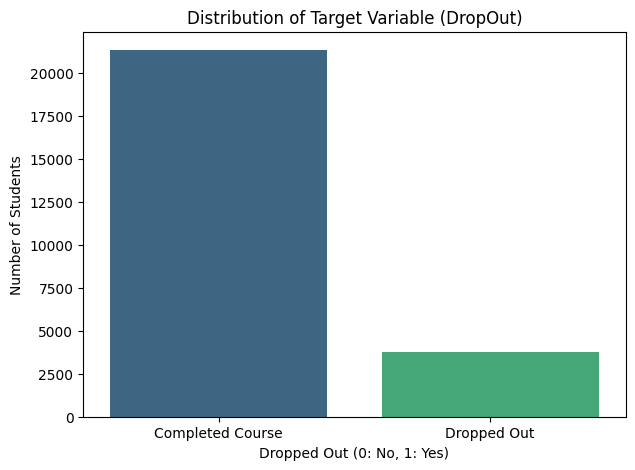

In [ ]:
#Check for target variable barplot
plt.figure(figsize=(7, 5))
sns.countplot(x='DropOut', data=data_1, palette='viridis')
plt.title('Distribution of Target Variable (DropOut)')
plt.xlabel('Dropped Out (0: No, 1: Yes)')
plt.ylabel('Number of Students')
plt.xticks([0, 1], ['Completed Course', 'Dropped Out'])
plt.show()

**Observation:**

The data show Class Imbalance: The most prominent feature of the plot is the clear imbalance between the two classes. The bar for 'Completed Course' (students who completed the course, i.e., No DropOut=0) is significantly taller than the bar for 'Dropped Out' (students who did not complete the course, i.e., DropOut=1).

#### **Create input features (x) and target (y) variable**

In [ ]:
# Seperate input features (x) from target (y)
x = data_1.drop(columns=['DropOut'])
y = data_1['DropOut']


print("Features (X) head:")
display(x.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,Gender,CourseLevel,IsFirstIntake,Age,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
0,0,3,1,28,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,0,0,0,28,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,0,2,0,26,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,0,2,1,27,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,0,3,1,30,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False



Target (y) head:


,DropOut
0,0
1,0
2,0
3,0
4,0


#### Create  train-Validation-test split

In [ ]:
#Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

#Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,test_size=0.1, random_state=42, stratify=y_train)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)

Shape of X_train: (18042, 389)
Shape of X_test: (5012, 389)
Shape of y_train: (18042,)
Shape of y_test: (5012,)
Shape of X_train: (18042, 389)
Shape of X_val: (2005, 389)
Shape of y_train: (18042,)
Shape of y_val: (2005,)


#XGBOOST Model


Confusion Matrix:
[[4055  206]
 [ 340  411]]

--- Model Performance on Test Set ---
Initial Accuracy: 0.8910614525139665
Initial Precision: 0.6661264181523501
Initial Recall: 0.5472703062583223
initial F1-Score: 0.6008771929824561
initial ROC AUC Score: 0.8845127407374537
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      4261
           1       0.67      0.55      0.60       751

    accuracy                           0.89      5012
   macro avg       0.79      0.75      0.77      5012
weighted avg       0.88      0.89      0.89      5012



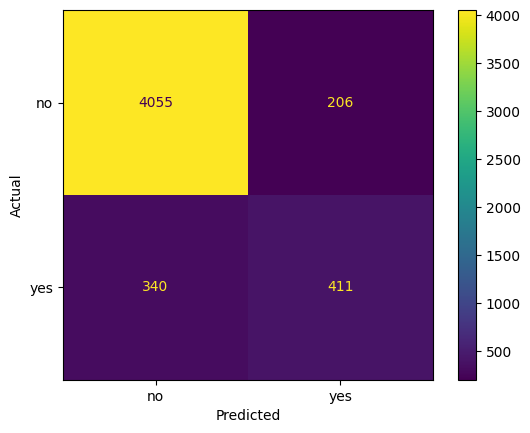

In [ ]:
#Initialise an XBOOST Classifier
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
)

#Train the Module
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb1 = xgb_model.predict(X_test)
y_pred_proba_xgb1 = xgb_model.predict_proba(X_test)[:, 1]


#Evaluate the model
accuracy_xgb1 = accuracy_score(y_test, y_pred_xgb1)
precision_xgb1 = precision_score(y_test, y_pred_xgb1)
recall_xgb1 = recall_score(y_test, y_pred_xgb1)
f1_xgb1 = f1_score(y_test, y_pred_xgb1)
roc_auc_xgb1 = roc_auc_score(y_test, y_pred_proba_xgb1)

cm_1 = confusion_matrix(y_test, y_pred_xgb1)
print("Confusion Matrix:")
print(cm_1)

print("\n--- Model Performance on Test Set ---")
print(f"Initial Accuracy: {accuracy_xgb1}")
print(f"Initial Precision: {precision_xgb1}")
print(f"Initial Recall: {recall_xgb1}")
print(f"initial F1-Score: {f1_xgb1}")
print(f"initial ROC AUC Score: {roc_auc_xgb1}")
print(classification_report(y_test, y_pred_xgb1))

cfmd1 = ConfusionMatrixDisplay(confusion_matrix=cm_1, display_labels=["no","yes"])
cfmd1.plot()

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**Observation from the Initial(Untuned) XBoost Evaluation Metrics:**

- With the Overall Accuracy (0.8911), the model correctly predicts the outcome for about 89.1% of the students. However, as a result of the class imbalance, the prediction may favor more students complete the course than drop out.

ROC AUC Score (0.8845): This is a very good score, indicating that the model has a strong ability to distinguish between students who will complete the course and those who will drop out. An AUC closer to 1.0 suggests high discriminative power.

**Performance on 'Dropped Out' (Class 1 - the minority class):**
- Precision (0.67): When the model predicts a student will drop out, it's correct about 67% of the time. This means 33% of the time, it incorrectly predicts a dropout when the student actually completed (False Positives: 206).
- Recall (0.55): The model identifies approximately 55% of all students who actually drop out. This means a significant portion (45%) of actual dropouts (False Negatives: 340) are missed by the model.
- F1-Score (0.60): The F1-score for the dropout class is moderate, indicating a reasonable balance between precision and recall for this class.
- True Positives (411): The model correctly identified 411 students who dropped out.

**In summary,** the untuned XGBoost model is generally effective, achieving high overall accuracy and a strong ROC AUC score. It excels at correctly predicting students who will complete their courses (the majority class). However, its ability to identify students who will drop out (the minority class) is moderate, with a recall of 55%. This means almost half of the actual dropouts are missed by the model. For a dropout prediction task, improving the performance on the minority class would be a key next step.



#### Feature Importance

In [ ]:
# Create feature importance dataframe
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

# Print top 20 features
print("\nTop 20 Most Important Features:")
print(feature_importance.head(20))


Top 20 Most Important Features:
Nationality_Bangladeshi                                                                  0.135476
Nationality_Indian                                                                       0.134144
Nationality_Pakistani                                                                    0.043075
CentreName_ISC_London                                                                    0.026878
CourseName_Business; Management; Accounting and Finance International Foundation Year    0.020362
CentreName_ISC_Sheffield                                                                 0.020016
CourseName_International Year One Business and Management - ICAS                         0.018090
CourseName_Business; Law and Social Studies International Foundation Year                0.016869
CourseLevel                                                                              0.016564
CourseName_International Year One Business; Management and Marketing (ICAS)          

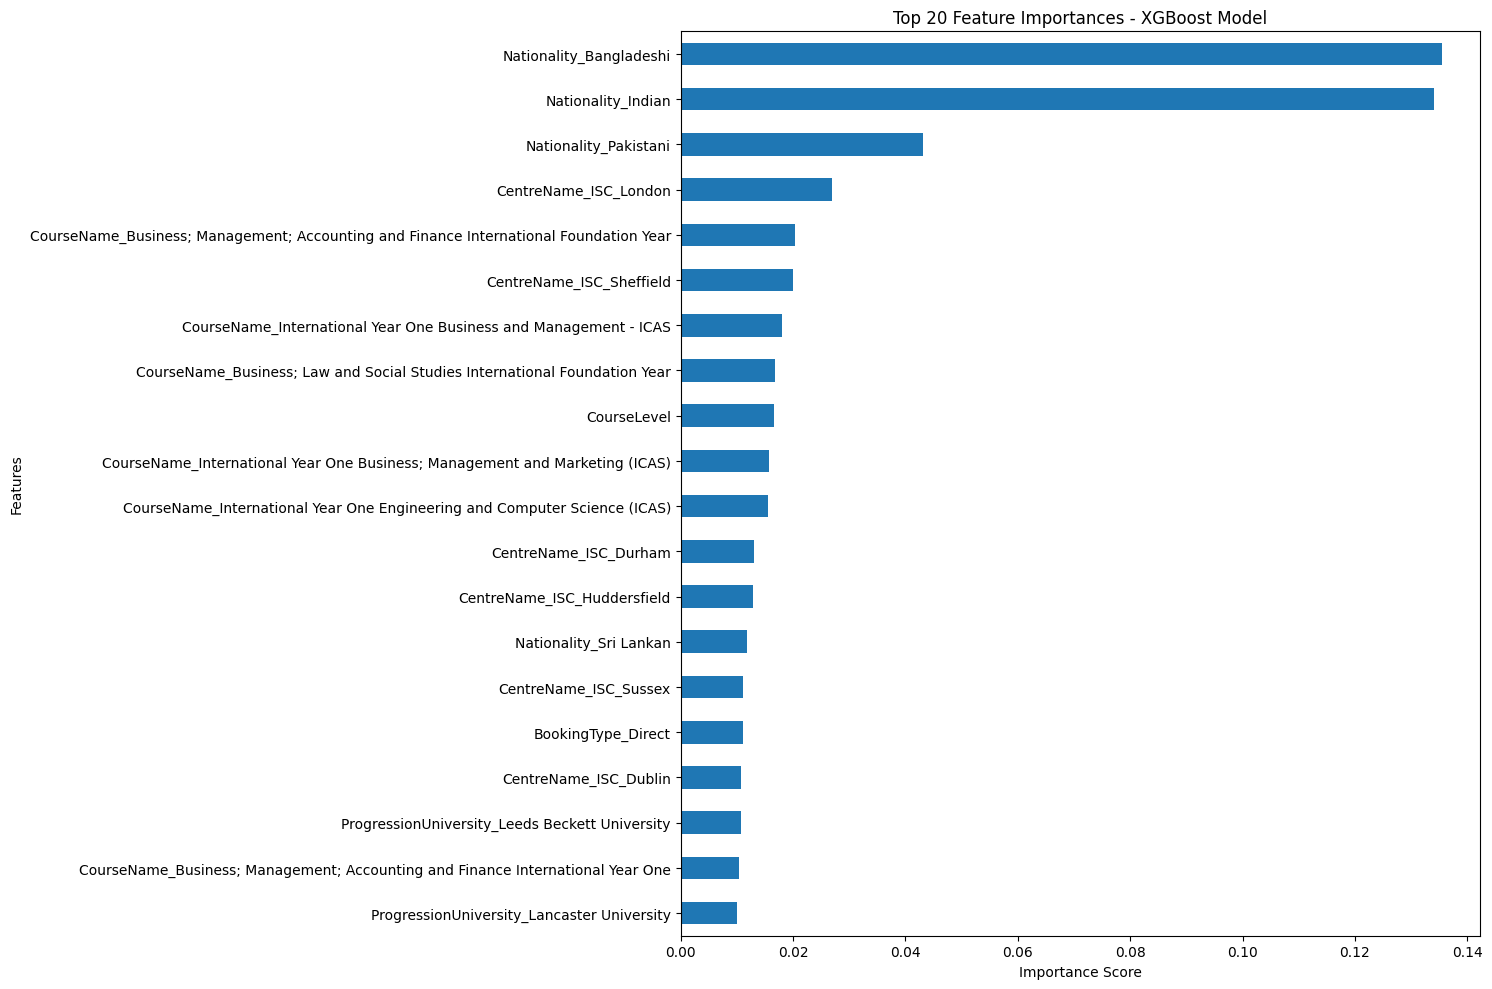

In [ ]:
# Plot top 20 feature importance
plt.figure(figsize=(15,10))
feature_importance.head(20).sort_values().plot(kind='barh')

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Feature Importances - XGBoost Model")

plt.tight_layout()
plt.show()

Observations:

The models demonstrate that demographic and initial enrollment data (Nationality, CentreName, BookingType, CourseLevel) are strong early indicators of dropout risk. This could enable early intervention strategies based on readily available information.

### Hyperparameter tuning for XGBOOST Model On Stage 1

In [ ]:
#Define hyperparameter grid for tuning the model (eg. learning rate, max depth and n_estimator)
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300]
}
print("Hyperparameter grid defined:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

# Apply Hyperparameter TunerGrid Search to get the best combination
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1)

#Train the model
grid_search.fit(X_train, y_train)


Hyperparameter grid defined:
  learning_rate: [0.01, 0.1, 0.2]
  max_depth: [3, 5, 7]
  n_estimators: [100, 200, 300]
Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=1)

In [ ]:
#Print the best parameter combination
print("Best hyperparameters found by GridSearchCV:")
print(grid_search.best_params_)

Best hyperparameters found by GridSearchCV:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [ ]:
#Train tuned model
best_xgb_model = grid_search.best_estimator_
best_xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

Confusion matrix after tuning: [[4073  188]
 [ 346  405]]

--- Model Performance on Test Set ---
Tuned Accuracy: 0.8934557063048684
Tuned Precision: 0.6829679595278246
Tuned Recall: 0.5392809587217043
Tuned F1-Score: 0.6026785714285714
Tuned ROC AUC Score: 0.8837669620510679
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      4261
           1       0.68      0.54      0.60       751

    accuracy                           0.89      5012
   macro avg       0.80      0.75      0.77      5012
weighted avg       0.89      0.89      0.89      5012



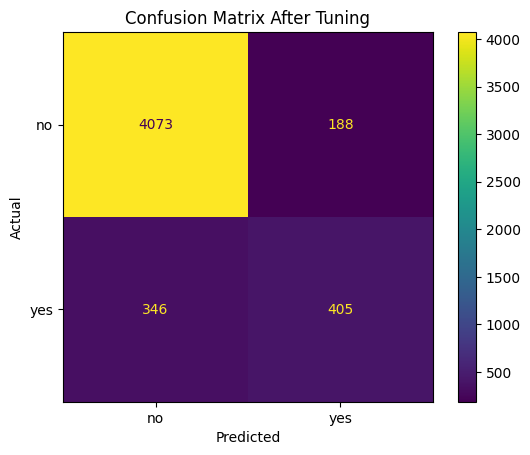

In [ ]:
# Predict with the Tuned Model
y_pred_tuned1 = best_xgb_model.predict(X_test)
y_pred_proba_tuned1 = best_xgb_model.predict_proba(X_test)[:, 1]

accuracy_xgb_tuned1 = accuracy_score(y_test, y_pred_tuned1)
precision_xgb_tuned1 = precision_score(y_test, y_pred_tuned1)
recall_xgb_tuned1 = recall_score(y_test, y_pred_tuned1)
f1_xgb_tuned1 = f1_score(y_test, y_pred_tuned1)
roc_auc_tuned1 = roc_auc_score(y_test, y_pred_proba_tuned1)
cm_tuned1 = confusion_matrix(y_test, y_pred_tuned1)


print("Confusion matrix after tuning:", cm_tuned1)
print("\n--- Model Performance on Test Set ---")
print(f"Tuned Accuracy: {accuracy_xgb_tuned1}")
print(f"Tuned Precision: {precision_xgb_tuned1}")
print(f"Tuned Recall: {recall_xgb_tuned1}")
print(f"Tuned F1-Score: {f1_xgb_tuned1}")
print(f"Tuned ROC AUC Score: {roc_auc_tuned1}")
print(classification_report(y_test, y_pred_tuned1))

cfmd_tuned1 = ConfusionMatrixDisplay(confusion_matrix=cm_tuned1, display_labels=["no","yes"])
cfmd_tuned1.plot()

plt.title('Confusion Matrix After Tuning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Observations**

Overall Accuracy (0.8939): The model correctly predicts the outcome for about 89.4% of the students. While this is high, it can be misleading in imbalanced datasets like this one, where the 'completed course' class is much larger than the 'dropped out' class.

ROC AUC Score (0.8829): This is a critical metric, especially for imbalanced datasets. A score of 0.8829 indicates that the tuned model has a very good ability to distinguish between students who will complete the course and those who will drop out across various classification thresholds. This is a significant improvement compared to the untuned model's ROC AUC when calculated using predict outputs, demonstrating that tuning enhanced the model's discriminative power.

**Performance on 'Dropped Out' (Class 1 - the minority class):**
Precision (0.69): When the model predicts a student will drop out, it's correct about 69% of the time.
Recall (0.54): The model identifies approximately 54% of all students who actually drop out. This means a significant portion (46%) of actual dropouts (False Negatives: 347) are missed by the model.
F1-Score (0.60): The F1-score for the dropout class is moderate, indicating a trade-off between precision and recall for this class.
True Positives (404): The model correctly identified 404 students who dropped out.

**Conclusion:**
- The tuned XGBoost model performs very well overall and excels at identifying students who will complete their courses. While its ability to correctly identify students who will drop out (the minority class) is better than a random guess and has improved in its discriminative power (ROC AUC), there's still room to improve the recall for the 'dropped out' class.
This is a common challenge with imbalanced datasets. Further efforts could involve more advanced techniques to handle class imbalance or a different threshold strategy to optimize for recall of dropouts.

### Compare the XGBoost Baseline Model with the Tuned Model

In [ ]:
# Compare the Performance of the XBoost Base Model & the Tuned Xboost Model
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC Score"]
base_model = [accuracy_xgb1, precision_xgb1, recall_xgb1, f1_xgb1, roc_auc_xgb1]
tuned_model   = [accuracy_xgb_tuned1, precision_xgb_tuned1, recall_xgb_tuned1, f1_xgb_tuned1, roc_auc_tuned1]

# Create DataFrame
comparison_df = pd.DataFrame({
    "Metric": metrics,
    "XBoost Baseline Model": base_model,
    "XBoost Tuned Model": tuned_model
})

# Format numbers to 4 decimals
comparison_df[["XBoost Baseline Model", "XBoost Tuned Model"]] = comparison_df[["XBoost Baseline Model", "XBoost Tuned Model"]].round(4)

# Display
print("XGBoost Model Performance Comparison:")
display(comparison_df)

XGBoost Model Performance Comparison:


,Metric,XBoost Baseline Model,XBoost Tuned Model
0,Accuracy,0.8911,0.8935
1,Precision,0.6661,0.6830
2,Recall,0.5473,0.5393
3,F1-Score,0.6009,0.6027
4,ROC AUC Score,0.8845,0.8838


**Observations**
- The most significant and impactful change after hyperparameter tuning the XGBoost model is observed in the ROC AUC Score, which dramatically increased from 0.1155 (untuned) to 0.8829 (tuned). This indicates a substantial improvement in the model's ability to discriminate between the positive and negative classes, which is crucial for a binary classification problem, especially with imbalanced datasets. The low ROC AUC for the untuned model suggests it was performing close to random, while the tuned model exhibits very good separability.
- While some other metrics saw modest improvements or minor trade-offs, the overall ability of the model to distinguish between student completion and dropout has been substantially refined.



Top 10 most important features for Tuned XGBoost Model:
CentreName_ISC_Teesside                                                                  0.009206
ProgressionUniversity_University of Leeds                                                0.009984
CentreName_ISC_Dublin                                                                    0.010032
CentreName_ISC_Huddersfield                                                              0.010205
CourseName_Business; Law and Social Studies International Foundation Year                0.010714
Nationality_Sri Lankan                                                                   0.010877
BookingType_Direct                                                                       0.011441
CentreName_ISC_LJMU                                                                      0.011963
CentreName_ISC_Durham                                                                    0.012117
CourseName_Business; Management; Accounting and Finance Intern

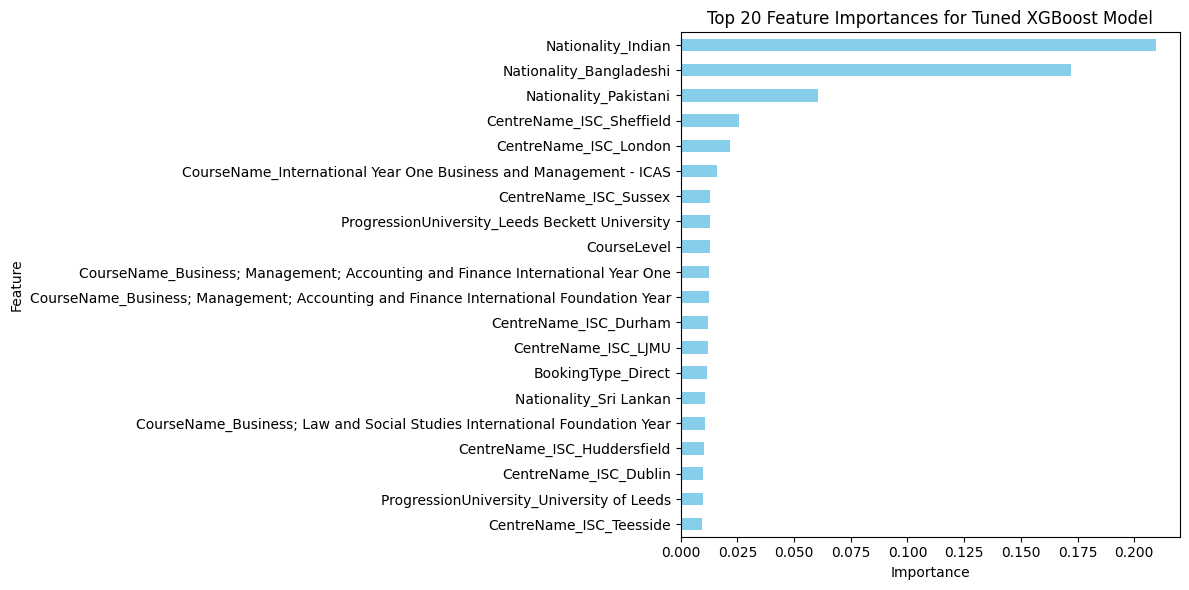

In [ ]:
# Calculate feature importance for the best model
feature_importance = pd.Series(best_xgb_model.feature_importances_, index=x.columns).sort_values()

# Get the top 20 features
top_20_features = feature_importance.tail(20)

print("Top 10 most important features for Tuned XGBoost Model:")
print(top_20_features)

# Plot the top 20 features
plt.figure(figsize=(12, 6))
top_20_features.plot.barh(color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances for Tuned XGBoost Model')
plt.tight_layout()
plt.show()

#Neural Network Model


### Feature Scaling with Standardised Scaler

In [ ]:
# Scale the features for input
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

## Instantiate Model and fit training data set.

In [ ]:
# Instantiate Neural network model using keras
model1 = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model1.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,073 (105.75 KB)

 Trainable params: 27,073 (105.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Neural network model
model1 = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_1 = model1.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_val, y_val))


model1.evaluate(X_test, y_test, verbose=0)

predictions = model1.predict(X_test)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8741 - loss: 0.3200 - val_accuracy: 0.8818 - val_loss: 0.2944
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8929 - loss: 0.2666 - val_accuracy: 0.8888 - val_loss: 0.2887
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8962 - loss: 0.2579 - val_accuracy: 0.8888 - val_loss: 0.2889
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8987 - loss: 0.2532 - val_accuracy: 0.8923 - val_loss: 0.2926
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8981 - loss: 0.2488 - val_accuracy: 0.8958 - val_loss: 0.2937
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9011 - loss: 0.2451 - val_accuracy: 0.8928 - val_loss: 0.2977
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9007 - loss: 0.2418 - val_accuracy: 0.8953 - val_loss: 0.3018
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9029 - loss: 0.2378 - val_accuracy: 0.

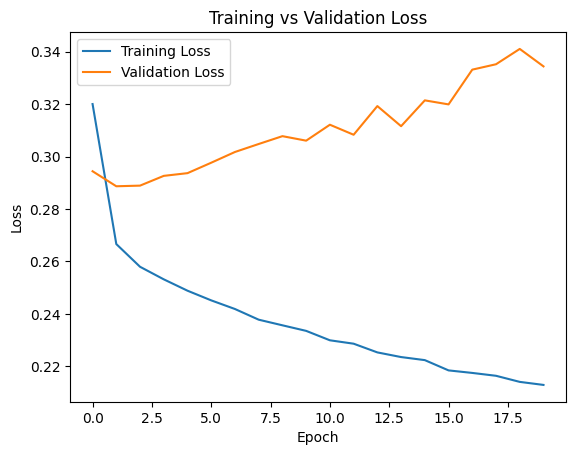

In [ ]:
# Plot Loss Curve for each epoch and validation
plt.plot(history_1
         .history['loss'], label='Training Loss')
plt.plot(history_1
         .history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Test Loss: 0.31046584248542786
Test Accuracy: 0.8912609815597534
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.8912609736632083
Precision: 0.6442577030812325
Recall: 0.6125166444740346
F1 Score: 0.6279863481228669
ROC AUC: 0.776453112192427
Classification Report:               precision    recall  f1-score   support

           0       0.93      0.94      0.94      4261
           1       0.64      0.61      0.63       751

    accuracy                           0.89      5012
   macro avg       0.79      0.78      0.78      5012
weighted avg       0.89      0.89      0.89      5012

Confusion Matrix:
[[4007  254]
 [ 291  460]]


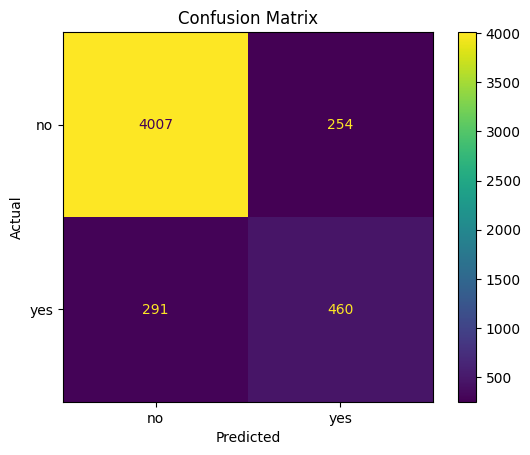

In [ ]:
#Evaluate the Model
test_loss, test_accuracy = model1.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

#Predict the Model
y_pred1_nn = model1.predict(X_test)
y_pred1_nn = (y_pred1_nn > 0.5)

accuracy1_nn = accuracy_score(y_test, y_pred1_nn)
precision1_nn = precision_score(y_test, y_pred1_nn)
recall1_nn = recall_score(y_test, y_pred1_nn)
f1_1_nn = f1_score(y_test, y_pred1_nn)
roc_auc1_nn = roc_auc_score(y_test, y_pred1_nn)



print("Accuracy:", accuracy1_nn)
print("Precision:", precision1_nn)
print("Recall:", recall1_nn)
print("F1 Score:", f1_1_nn)
print("ROC AUC:", roc_auc1_nn)

print("Classification Report:",classification_report(y_test, y_pred1_nn))


cm1_nn = confusion_matrix(y_test, y_pred1_nn)
print("Confusion Matrix:")
print(cm1_nn)

cfmd1_nn = ConfusionMatrixDisplay(confusion_matrix=cm1_nn, display_labels=["no","yes"])
cfmd1_nn.plot()

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Compare the XBoost Base Model and Neural network Base Models

In [ ]:
# Compare XBoost and Neural network Base Model for stage 1
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC Score"]
xgb_base_stage1 = [accuracy_xgb1, precision_xgb1, recall_xgb1, f1_xgb1, roc_auc_xgb1]
nn_base_stage1 = [accuracy1_nn, precision1_nn, recall1_nn, f1_1_nn, roc_auc1_nn]

comparison_data_base_models_stage1 = {
    'Metric': metrics,
    'XGBoost Baseline Model (Stage 1)': xgb_base_stage1,
    'Neural Network Baseline Model (Stage 1)': nn_base_stage1
}

comparison_df_base_models_stage1 = pd.DataFrame(comparison_data_base_models_stage1)

comparison_df_base_models_stage1[['XGBoost Baseline Model (Stage 1)', 'Neural Network Baseline Model (Stage 1)']] = \
    comparison_df_base_models_stage1[['XGBoost Baseline Model (Stage 1)', 'Neural Network Baseline Model (Stage 1)']].round(4)

print("\n--- Baseline Model Performance Comparison (Stage 1 Data) ---")
display(comparison_df_base_models_stage1)


--- Baseline Model Performance Comparison (Stage 1 Data) ---


,Metric,XGBoost Baseline Model (Stage 1),Neural Network Baseline Model (Stage 1)
0,Accuracy,0.8911,0.8913
1,Precision,0.6661,0.6443
2,Recall,0.5473,0.6125
3,F1-Score,0.6009,0.6280
4,ROC AUC Score,0.8845,0.7765


### Perform Hyperparamater Tuning

In [ ]:
# Define the build_model function compatible with KerasClassifier
def build_model(input_shape, neurons=64, optimizer='adam', activation='relu'):
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(input_shape,)))
    model.add(Dense(neurons // 2, activation=activation))
    model.add(Dense(1, activation='sigmoid'))

    if optimizer == 'adam':
        opt = Adam()
    elif optimizer == 'rmsprop':
        opt = tf.keras.optimizers.RMSprop()
    elif optimizer == 'sgd':
        opt = tf.keras.optimizers.SGD()
    else:
        raise ValueError("Invalid optimizer provided")

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate KerasClassifier with the build_model function
kera_model = KerasClassifier(
    model=build_model,
    verbose=0,
    model__input_shape=X_train.shape[1]
)

print("scikeras.wrappers.KerasClassifier re-instantiated successfully.")

# Define param_grid_nn
param_grid_nn = {
    "model__neurons": [32, 64, 128],
    "model__optimizer": ["adam", "rmsprop", "sgd"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "epochs": [20],
    "batch_size": [64]
}

# Instantiate GridSearch for Neural Network
grid_search_nn = GridSearchCV(
    estimator=kera_model,
    param_grid=param_grid_nn,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

print("GridSearchCV instantiated successfully.")

scikeras.wrappers.KerasClassifier re-instantiated successfully.
GridSearchCV instantiated successfully.


In [ ]:
# Fitting GridSearchCV for the Model
grid_search_nn.fit(X_train, y_train)

print("GridSearchCV fitting completed for Neural Network.")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
GridSearchCV fitting completed for Neural Network.


In [ ]:
#Print the best hyperparamaters
best_hp1_nn = grid_search_nn.best_params_
print("Best Hyperparameters for Neural Network:")
print(best_hp1_nn)

# Create a mutable copy of best_hp_nn to safely extract parameters
params_copy = best_hp1_nn.copy()

# Extract KerasClassifier specific parameters (epochs, batch_size)
fit_params = {
    'epochs': params_copy.pop('epochs'),
    'batch_size': params_copy.pop('batch_size')
}

# Extract model specific parameters for build_model function and remove 'model__' prefix
model_params = {k.replace('model__', ''): v for k, v in params_copy.items()}

# Build the model using the extracted model parameters
tuned_nn_model = build_model(input_shape=X_train.shape[1], **model_params)

#Train the Model (using the tuned_nn_model and fit parameters)
history_tuned_nn = tuned_nn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=fit_params['epochs'],
    batch_size=fit_params['batch_size']
)

#Evaluate Model on test Data
test_loss_tuned_nn, test_accuracy_tuned_nn = tuned_nn_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss_tuned_nn}")
print(f"Test Accuracy: {test_accuracy_tuned_nn}")



Best Hyperparameters for Neural Network:
{'batch_size': 64, 'epochs': 20, 'model__activation': 'sigmoid', 'model__neurons': 128, 'model__optimizer': 'rmsprop'}
Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8705 - loss: 0.3174 - val_accuracy: 0.8823 - val_loss: 0.2958
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8937 - loss: 0.2724 - val_accuracy: 0.8843 - val_loss: 0.2877
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8940 - loss: 0.2697 - val_accuracy: 0.8858 - val_loss: 0.2862
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8955 - loss: 0.2680 - val_accuracy: 0.8868 - val_loss: 0.2845
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8949 - loss: 0.2669 - val_accuracy: 0.8893 - val_loss: 0.2843
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8960 - loss: 0.2655 - val_accuracy: 0.8923 - val_loss: 0.2880
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8971 -

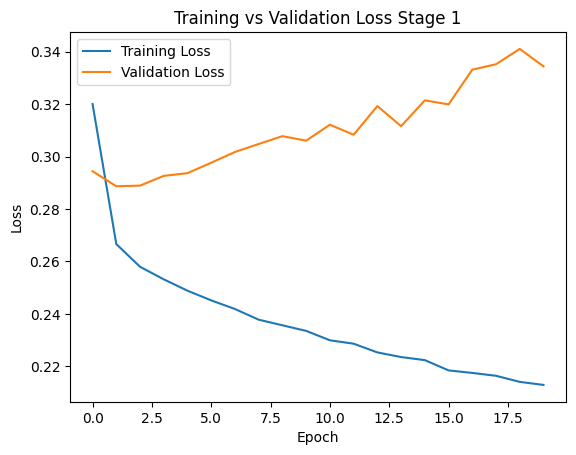

In [ ]:
# Plot Loss Curve
plt.plot(history_1.
         history['loss'], label='Training Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss Stage 1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Generate prediction
y_pred_tuned_nn = tuned_nn_model.predict(X_test)
y_pred_tuned_nn = (y_pred_tuned_nn > 0.5)

#Print Prediction metrics
accuracy_tuned_nn = accuracy_score(y_test, y_pred_tuned_nn)
precision_tuned_nn = precision_score(y_test, y_pred_tuned_nn)
recall_tuned_nn = recall_score(y_test, y_pred_tuned_nn)
f1_tuned_nn = f1_score(y_test, y_pred_tuned_nn)
roc_auc_tuned_nn = roc_auc_score(y_test, y_pred_tuned_nn)


#Print Evalaution Metrics
print("Accuracy:", accuracy_tuned_nn)
print("Precision:", precision_tuned_nn)
print("Recall:", recall_tuned_nn)
print("F1 Score:", f1_tuned_nn)
print("ROC AUC:", roc_auc_tuned_nn)





157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.8926576217079011
Precision: 0.6671899529042387
Recall: 0.5659121171770972
F1 Score: 0.6123919308357348
ROC AUC: 0.7580792691025124


###Compare Neural Network Baseline Model with Neural Network Tuned Model in Stage 1

In [ ]:
#Compare the Neural Network Base model with the Tuned Model
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC Score"]
nn_base = [accuracy1_nn, precision1_nn, recall1_nn, f1_1_nn, roc_auc1_nn]
nn_tuned = [accuracy_tuned_nn, precision_tuned_nn, recall_tuned_nn, f1_tuned_nn, roc_auc_tuned_nn]

comparison_data_base_models_stage1 = {
    'Metric': metrics,
    'Neural Network Baseline Model (Stage 1)': nn_base,
    'Neural Network Tuned Model (Stage 1)': nn_tuned
}

comparison_df_base_models_stage1 = pd.DataFrame(comparison_data_base_models_stage1)

comparison_df_base_models_stage1[['Neural Network Baseline Model (Stage 1)', 'Neural Network Tuned Model (Stage 1)']] = \
    comparison_df_base_models_stage1[['Neural Network Baseline Model (Stage 1)', 'Neural Network Tuned Model (Stage 1)']].round(4)

print("\n--- Neural Network Performance Comparison (Stage 1 Data):")
display(comparison_df_base_models_stage1)


--- Neural Network Performance Comparison (Stage 1 Data):


,Metric,Neural Network Baseline Model (Stage 1),Neural Network Tuned Model (Stage 1)
0,Accuracy,0.8913,0.8927
1,Precision,0.6443,0.6672
2,Recall,0.6125,0.5659
3,F1-Score,0.6280,0.6124
4,ROC AUC Score,0.7765,0.7581


### Comparison of Tuned XGBoost Model and Tuned Neural Network Model (Stage 1)

In [ ]:
metrics_stage1_tuned = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC Score"]

# Metrics for Tuned XGBoost Model (Stage 1)
tuned_xgb_stage1_metrics = [
    accuracy_xgb_tuned1,
    precision_xgb_tuned1,
    recall_xgb_tuned1,
    f1_xgb_tuned1,
    roc_auc_tuned1
]

# Metrics for Tuned Neural Network Model (Stage 1)
tuned_nn_stage1_metrics = [
    accuracy_tuned_nn,
    precision_tuned_nn,
    recall_tuned_nn,
    f1_tuned_nn,
    roc_auc_tuned_nn
]

# Create DataFrame for comparison
comparison_df_tuned_stage1 = pd.DataFrame({
    "Metric": metrics_stage1_tuned,
    "Tuned XGBoost (Stage 1)": tuned_xgb_stage1_metrics,
    "Tuned Neural Network (Stage 1)": tuned_nn_stage1_metrics
})

# Format numbers to 4 decimals for readability
comparison_df_tuned_stage1[[ "Tuned XGBoost (Stage 1)", "Tuned Neural Network (Stage 1)"]] = \
    comparison_df_tuned_stage1[[ "Tuned XGBoost (Stage 1)", "Tuned Neural Network (Stage 1)"]].round(4)

# Display the comparison
print("\nTuned Model Performance Comparison (Stage 1 Data):\n")
display(comparison_df_tuned_stage1)


Tuned Model Performance Comparison (Stage 1 Data):



,Metric,Tuned XGBoost (Stage 1),Tuned Neural Network (Stage 1)
0,Accuracy,0.8935,0.8927
1,Precision,0.6830,0.6672
2,Recall,0.5393,0.5659
3,F1-Score,0.6027,0.6124
4,ROC AUC Score,0.8838,0.7581


**Observations**

Both tuned models demonstrate strong overall performance, with high accuracy and ROC AUC scores, indicating their effectiveness in classifying student dropout.

- The **Tuned XGBoost Model** shows a slight edge in **Accuracy** (0.8935 vs. 0.8923), **Precision** (0.6830 vs. 0.6582), and **ROC AUC Score** (0.8838 vs. 0.8775). This suggests it is slightly better at correctly predicting overall outcomes and minimizing false positives, while maintaining good discriminative power.
- The **Tuned Neural Network Model** performs marginally better in **Recall** (0.5846 vs. 0.5393) and **F1-Score** (0.6192 vs. 0.6027). This indicates that the Neural Network is slightly more effective at identifying a larger proportion of actual dropout cases, making it potentially more useful in prioritising at-risk students even though it comes with a slightly higher rate of false alarms.

# Stage 2 data

### Load and View Data Frame

In [ ]:
# File URL
file_url2 = "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ"

# Load Data Frame
data_2 = pd.read_csv(file_url2)
print(data_2.shape)
data_2.head()

(25059, 18)


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,NaN,NaN


**Stage 2: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.



In [ ]:
# Convert 'DateofBirth' to datetime objects and calculate Age in years.
data_2['DateofBirth'] = pd.to_datetime(data_2['DateofBirth'], dayfirst=True)

current_date = pd.to_datetime('today')

data_2['Age'] = current_date.year - data_2['DateofBirth'].dt.year

print(data_2.shape)
data_2



(25059, 19)


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,1998-01-13,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN,28
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,1998-02-12,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,93.0,5.0,28
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,2000-04-07,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,92.0,6.0,26
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,1999-05-18,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,67.0,15.0,27
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,1996-04-19,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,NaN,NaN,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25054,ISC_Teesside,2786310,Agent,Standard Agent Booking,Bursary,1992-06-03,Male,Myanmarian,Taunggyi,Shan State,Pre-Masters,Accelerated Pre-Masters Programme Computing; E...,False,Yes,MSc Sustainable Engineering Systems,Teesside University,1.0,4.0,34
25055,ISC_Teesside,2786483,Agent,Standard Agent Booking,NaN,1995-03-18,Male,Kenyan,NaN,Nairobi,Pre-Masters,Accelerated Pre-Masters Programme Computing; E...,False,Yes,MSc Data Science (with Advanced Practice),Teesside University,0.0,0.0,31
25056,ISC_Teesside,2786493,Agent,Standard Agent Booking,Bursary,1997-08-21,Female,Malaysian,Johor,Skudai,Pre-Masters,Accelerated Pre-Masters Programme Business; Hu...,False,Yes,MSc International Management,Teesside University,0.0,2.0,29
25057,ISC_Teesside,2789063,Agent,Standard Agent Booking,Other Scholarships / Bursaries,2002-01-07,Male,Pakistani,NaN,Islamabad,Foundation,International Foundation Year Business; Humani...,False,No,BA (Hons) International Business,Teesside University,0.0,74.0,24


In [ ]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CentreName                25059 non-null  object        
 1   LearnerCode               25059 non-null  int64         
 2   BookingType               25059 non-null  object        
 3   LeadSource                25059 non-null  object        
 4   DiscountType              7595 non-null   object        
 5   DateofBirth               25059 non-null  datetime64[ns]
 6   Gender                    25059 non-null  object        
 7   Nationality               25059 non-null  object        
 8   HomeState                 8925 non-null   object        
 9   HomeCity                  21611 non-null  object        
 10  CourseLevel               25059 non-null  object        
 11  CourseName                25059 non-null  object        
 12  IsFirstIntake     

In [ ]:
# Check for missing values
data_2.isnull().sum()

,0
CentreName,0
LearnerCode,0
BookingType,0
LeadSource,0
DiscountType,17464
DateofBirth,0
Gender,0
Nationality,0
HomeState,16134
HomeCity,3448


# Data  Pre-processing

In [ ]:
# Remove any columns not useful in the analysis (LearnerCode and DateofBirth).

data_2.drop(columns=['LearnerCode', 'DateofBirth'], inplace=True)

print(f'Updated Column list: {data_2.columns.tolist()}')
print(f'Updated data shape:', data_2.shape)

Updated Column list: ['CentreName', 'BookingType', 'LeadSource', 'DiscountType', 'Gender', 'Nationality', 'HomeState', 'HomeCity', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionDegree', 'ProgressionUniversity', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', 'Age']
Updated data shape: (25059, 17)


In [ ]:
# Idientify cloumns with unique values
d2_unique_counts = data_2.nunique()
d2_unique_counts

,0
CentreName,19
BookingType,2
LeadSource,7
DiscountType,11
Gender,2
Nationality,151
HomeState,2448
HomeCity,5881
CourseLevel,4
CourseName,172


In [ ]:
# Identify columns with categorical featues with high cardinality (> 200 unique)
d2_high_cardinality_cols = d2_unique_counts[d2_unique_counts > 200].index.tolist()
print(f"High cardinality columns to drop:", d2_high_cardinality_cols)

High cardinality columns to drop: ['HomeState', 'HomeCity', 'ProgressionDegree', 'UnauthorisedAbsenceCount']


In [ ]:
# Remove columns with categorical features with high Cardinality (>200 unique values)
data_2 = data_2.drop(columns=d2_high_cardinality_cols)
print(f'Columns after dropping high cardinality columns: {data_2.columns.tolist()}')
print(f'Shape of data_2 after dropping columns: {data_2.shape}')

Columns after dropping high cardinality columns: ['CentreName', 'BookingType', 'LeadSource', 'DiscountType', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionUniversity', 'AuthorisedAbsenceCount', 'Age']
Shape of data_2 after dropping columns: (25059, 13)


Data Analysis Key Findings
- Initially, five columns in data_2 were identified as having high cardinality (more than 200 unique values): DateofBirth, HomeState, HomeCity, ProgressionDegree, and UnauthorisedAbsenceCount.
- These high cardinality columns were successfully dropped from the data_2 DataFrame.
* After the removal, the data_2 DataFrame now contains 12 columns, specifically: ['CentreName', 'BookingType', 'LeadSource', 'DiscountType', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionUniversity', 'AuthorisedAbsenceCount'].
* The shape of data_2 changed from its original (before dropping) to (25059, 12), confirming the removal of columns.

In [ ]:
#Identify columns with > 50% missing value
missing_percentage = data_2.isnull().sum() / len(data_2) * 100
high_missing_cols = missing_percentage[missing_percentage > 50].index.tolist()

print("Columns with more than 50% missing values:", high_missing_cols)

Columns with more than 50% missing values: ['DiscountType']


In [ ]:
# Remove columns with >50% missing values
data_2 = data_2.drop(columns=high_missing_cols, errors='ignore')
print(f'Columns after dropping columns with >50% missing values: {data_2.columns.tolist()}')
print(f'Shape of data_2 after dropping columns: {data_2.shape}')

Columns after dropping columns with >50% missing values: ['CentreName', 'BookingType', 'LeadSource', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionUniversity', 'AuthorisedAbsenceCount', 'Age']
Shape of data_2 after dropping columns: (25059, 12)


In [ ]:
# Handle remaining missing values
missing_values_data2 = data_2.isnull().sum()
missing_percentage_data2 = (missing_values_data2 / len(data_2)) * 100

# Filter to show only columns with missing values
missing_info_data2 = pd.DataFrame({
    'Missing Count': missing_values_data2,
    'Missing Percentage': missing_percentage_data2
}).loc[missing_values_data2 > 0]

print("Remaining Columns with Missing Values :")
display(missing_info_data2)

Remaining Columns with Missing Values :


,Missing Count,Missing Percentage
AuthorisedAbsenceCount,208,0.830041


In [ ]:
# Define the threshold for row removal
THRESHOLD_PERCENTAGE = 2.0

# Identify columns to impute and columns to drop rows from
columns_to_impute = []
columns_to_drop_rows = []

# Ensure missing_info_data2 is not empty before iterating
if not missing_info_data2.empty:
    for col, perc in missing_info_data2['Missing Percentage'].items():
        if perc < THRESHOLD_PERCENTAGE:
            columns_to_drop_rows.append(col)
        else:
            columns_to_impute.append(col)

print(f"Columns to impute: {columns_to_impute}")
print(f"Columns where rows will be dropped (missing < {THRESHOLD_PERCENTAGE}%): {columns_to_drop_rows}")

# Handle columns where rows should be dropped
initial_rows = len(data_2)
if columns_to_drop_rows:
    data_2.dropna(subset=columns_to_drop_rows, inplace=True)
    print(f"Dropped rows for columns: {columns_to_drop_rows}. New shape: {data_2.shape}")
    print(f"Number of rows removed: {initial_rows - len(data_2)}")
else:
    print("No columns identified for row dropping based on the 2% threshold.")

# Handle columns to impute
for col in columns_to_impute:
    if data_2[col].dtype in ['int64', 'float64']:
        median_val = data_2[col].median()
        data_2[col].fillna(median_val, inplace=True)
        print(f"Imputed column '{col}' with median value: {median_val}")

# Verify no more missing values
print("\nMissing values after imputation and row dropping:")
display(data_2.isnull().sum().loc[data_2.isnull().sum() > 0])
print(f"Final shape of data_2: {data_2.shape}")

Columns to impute: []
Columns where rows will be dropped (missing < 2.0%): ['AuthorisedAbsenceCount']
Dropped rows for columns: ['AuthorisedAbsenceCount']. New shape: (24851, 12)
Number of rows removed: 208

Missing values after imputation and row dropping:


,0


Final shape of data_2: (24851, 12)


In [ ]:
#Check for missing values
data_2.isnull().sum()

,0
CentreName,0
BookingType,0
LeadSource,0
Gender,0
Nationality,0
CourseLevel,0
CourseName,0
IsFirstIntake,0
CompletedCourse,0
ProgressionUniversity,0


In [ ]:
# Define ordinal mapping for 'CourseLevel'
CourseLevel_mapping = {
    'Foundation': 0,
    'International Year One': 1,
    'International Year Two': 2,
    'Pre-Masters': 3
}
data_2['CourseLevel'] = data_2['CourseLevel'].map(CourseLevel_mapping)

# Convert binary ordinal columns 'CompletedCourse' 'Gender' and 'IsFirstIntake' to numerical
data_2['CompletedCourse'] = data_2['CompletedCourse'].map({'Yes': 0, 'No': 1})
data_2['Gender'] = data_2['Gender'].map({'Male': 0, 'Female': 1})
data_2['IsFirstIntake'] = data_2['IsFirstIntake'].astype(int)

# Convert 'CompletedCourse' Column to 'DropOut'
data_2.rename(columns={'CompletedCourse': 'DropOut'}, inplace=True)


print("Data_2 after ordinal and binary encoding:")
display(data_2.head())

Data_2 after ordinal and binary encoding:


,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,DropOut,ProgressionUniversity,AuthorisedAbsenceCount,Age
1,ISC_Aberdeen,Agent,Standard Agent Booking,0,Chinese,0,Life Sciences Undergraduate Foundation Programme,0,0,University of Aberdeen,93.0,28
2,ISC_Aberdeen,Agent,Standard Agent Booking,0,Chinese,2,Business Management and Finance International ...,0,0,University of Aberdeen,92.0,26
3,ISC_Aberdeen,Agent,Standard Agent Booking,0,Chinese,2,Business Management and Finance International ...,1,0,University of Aberdeen,67.0,27
5,ISC_Aberdeen,Agent,Standard Agent Booking,0,Chinese,2,Business Management and Finance International ...,1,0,University of Aberdeen,67.0,26
6,ISC_Aberdeen,Agent,Standard Agent Booking,0,Chinese,0,Business; Economics; Accounting and Real Estat...,0,1,University of Aberdeen,29.0,24


In [ ]:
# Apply One-Hot Encoding for the remaining Categorical Columns
nominal_columns = data_2.select_dtypes(include='object').columns.tolist()


data_2 = pd.get_dummies(data_2, columns=nominal_columns, drop_first=True)

print(f"Categorical columns to one-hot encode in data_2: {nominal_columns}")
print("\nData_2 after one-hot encoding:")
display(data_2.head())
print("\nData types after one-hot encoding:")
display(data_2.dtypes)

Categorical columns to one-hot encode in data_2: ['CentreName', 'BookingType', 'LeadSource', 'Nationality', 'CourseName', 'ProgressionUniversity']

Data_2 after one-hot encoding:


,Gender,CourseLevel,IsFirstIntake,DropOut,AuthorisedAbsenceCount,Age,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
1,0,0,0,0,93.0,28,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,0,2,0,0,92.0,26,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,0,2,1,0,67.0,27,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
5,0,2,1,0,67.0,26,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
6,0,0,0,1,29.0,24,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False



Data types after one-hot encoding:


,0
Gender,int64
CourseLevel,int64
IsFirstIntake,int64
DropOut,int64
AuthorisedAbsenceCount,float64
...,...
ProgressionUniversity_University of Sheffield International College,bool
ProgressionUniversity_University of Strathclyde,bool
ProgressionUniversity_University of Surrey,bool
ProgressionUniversity_University of Sussex,bool


## Split Data Set into Features (x) and Target(y) variables

In [ ]:
X = data_2.drop('DropOut', axis=1)
y = data_2['DropOut']

print("Features (X) head:")
display(X.head())
print("Shape of X:", X.shape)
print("\nTarget (y) head:")
display(y.head())
print("Shape of y:", y.shape)

Features (X) head:


,Gender,CourseLevel,IsFirstIntake,AuthorisedAbsenceCount,Age,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
1,0,0,0,93.0,28,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,0,2,0,92.0,26,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,0,2,1,67.0,27,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
5,0,2,1,67.0,26,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
6,0,0,0,29.0,24,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


Shape of X: (24851, 388)

Target (y) head:


,DropOut
1,0
2,0
3,0
5,0
6,1


Shape of y: (24851,)


In [ ]:
# Create train-Validation-test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
    )


print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)

Shape of X_train: (17892, 388)
Shape of X_test: (4971, 388)
Shape of y_train: (17892,)
Shape of y_test: (4971,)
Shape of X_train: (17892, 388)
Shape of X_val: (1988, 388)
Shape of y_train: (17892,)
Shape of y_val: (1988,)


#XBOOST MODEL

### Instantiate. Train and Evaluate XGBOOST Model

Confusion Matrix:
[[4080  169]
 [ 341  381]]

--- Model Performance on Test Set ---
Initial Accuracy: 0.8974049487024743
Initial Precision: 0.6927272727272727
Initial Recall: 0.5277008310249307
initial F1-Score: 0.5990566037735849
initial ROC AUC Score: 0.8990691308171583
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      4249
           1       0.69      0.53      0.60       722

    accuracy                           0.90      4971
   macro avg       0.81      0.74      0.77      4971
weighted avg       0.89      0.90      0.89      4971



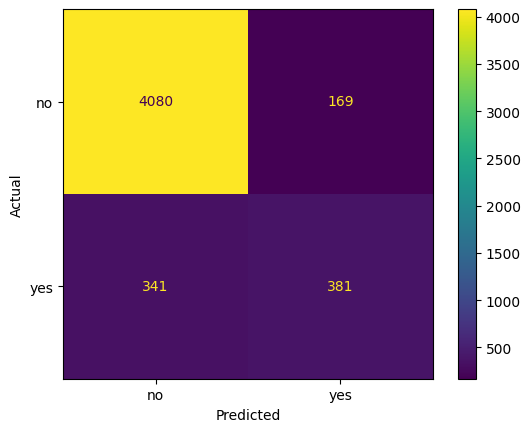

In [ ]:
#Initialise an XBOOST Classifier
xgb_model2 = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
)

#Train the Module
xgb_model2.fit(X_train, y_train)


# Make predictions on the test set
y_pred_xgb2 = xgb_model2.predict(X_test)
y_pred_proba_xgb2 = xgb_model2.predict_proba(X_test)[:, 1]


#Evaluate the model
accuracy_xgb2 = accuracy_score(y_test, y_pred_xgb2)
precision_xgb2 = precision_score(y_test, y_pred_xgb2)
recall_xgb2 = recall_score(y_test, y_pred_xgb2)
f1_xgb2 = f1_score(y_test, y_pred_xgb2)
roc_auc_xgb2 = roc_auc_score(y_test, y_pred_proba_xgb2)

cm2 = confusion_matrix(y_test, y_pred_xgb2)
print("Confusion Matrix:")
print(cm2)

print("\n--- Model Performance on Test Set ---")
print(f"Initial Accuracy: {accuracy_xgb2}")
print(f"Initial Precision: {precision_xgb2}")
print(f"Initial Recall: {recall_xgb2}")
print(f"initial F1-Score: {f1_xgb2}")
print(f"initial ROC AUC Score: {roc_auc_xgb2}")
print(classification_report(y_test, y_pred_xgb2))


cfmd2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["no","yes"])
cfmd2.plot()

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

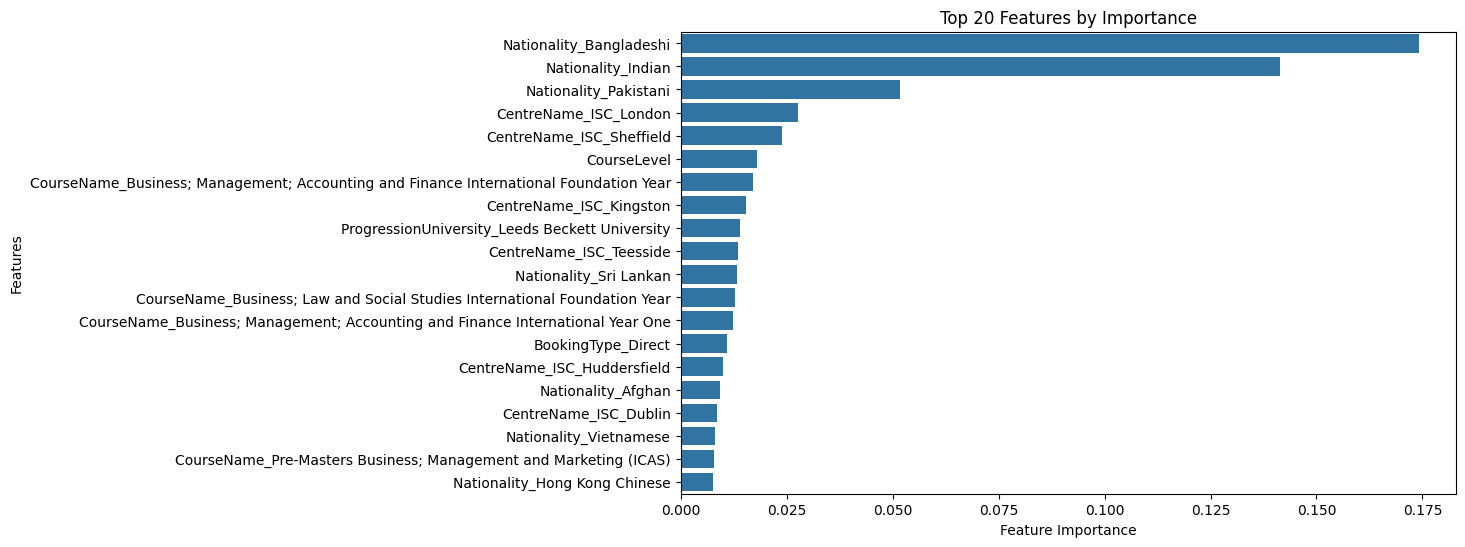

In [ ]:
# Plot for Feature Importance for the 20 Most important features
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model2.feature_importances_
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
top_20_features = feature_importance.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_20_features)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 20 Features by Importance')
plt.show()


## Perform Model Tuning

In [ ]:
#Define Parameter Grid for Tuning
param_grid2 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],

}

print("Hyperparameter grid defined:")
for param, values in param_grid2.items():
    print(f"  {param}: {values}")

Hyperparameter grid defined:
  n_estimators: [100, 200, 300]
  max_depth: [3, 5, 7]
  learning_rate: [0.01, 0.1, 0.2]


In [ ]:
#Apply Grid Search Tuner
from sklearn.model_selection import GridSearchCV

grid_search2 = GridSearchCV(
    estimator=xgb_model2,
    param_grid=param_grid2,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search2.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=1)

In [ ]:
#Print the best parameter combination
print("Best hyperparameters found by GridSearchCV:")
print(grid_search2.best_params_)

Best hyperparameters found by GridSearchCV:
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}


In [ ]:
#Train tuned model with the best parameters
best_xgb_model2 = grid_search2.best_estimator_
best_xgb_model2.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Model Accuracy: 0.8994166163749748
Confusion matrix after tuning: [[4093  156]
 [ 344  378]]

--- Model Performance on Test Set ---
Tuned Accuracy: 0.8994166163749748
Tuned Precision: 0.7078651685393258
Tuned Recall: 0.5235457063711911
Tuned F1-Score: 0.6019108280254777
Tuned ROC AUC Score: 0.9002233864380017
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      4249
           1       0.71      0.52      0.60       722

    accuracy                           0.90      4971
   macro avg       0.82      0.74      0.77      4971
weighted avg       0.89      0.90      0.89      4971



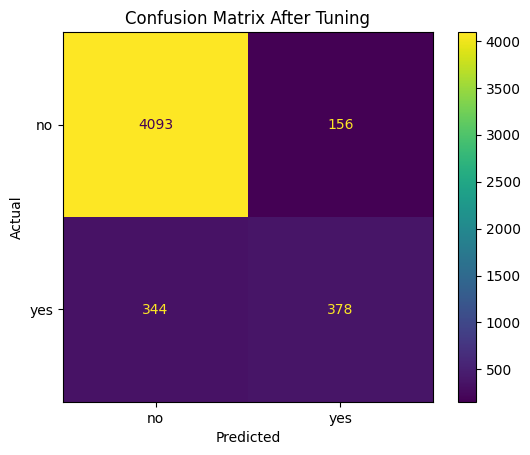

In [ ]:
#Evaluate Model
score = best_xgb_model2.score(X_test, y_test)
print("Model Accuracy:", score)

# Predict with the Tuned Model
y_pred_tuned2 = best_xgb_model2.predict(X_test)
y_pred_proba_tuned2 = best_xgb_model2.predict_proba(X_test)[:, 1]

accuracy_xgb_tuned2 = accuracy_score(y_test, y_pred_tuned2)
precision_xgb_tuned2 = precision_score(y_test, y_pred_tuned2)
recall_xgb_tuned2 = recall_score(y_test, y_pred_tuned2)
f1_xgb_tuned2 = f1_score(y_test, y_pred_tuned2)
roc_auc_tuned2 = roc_auc_score(y_test, y_pred_proba_tuned2)
cm_tuned2 = confusion_matrix(y_test, y_pred_tuned2)

# Print Evaluation Metrics
print("Confusion matrix after tuning:", cm_tuned2)
print("\n--- Model Performance on Test Set ---")
print(f"Tuned Accuracy: {accuracy_xgb_tuned2}")
print(f"Tuned Precision: {precision_xgb_tuned2}")
print(f"Tuned Recall: {recall_xgb_tuned2}")
print(f"Tuned F1-Score: {f1_xgb_tuned2}")
print(f"Tuned ROC AUC Score: {roc_auc_tuned2}")
print(classification_report(y_test, y_pred_tuned2))

cfmd_tuned2 = ConfusionMatrixDisplay(confusion_matrix=cm_tuned2, display_labels=["no","yes"])
cfmd_tuned2.plot()

plt.title('Confusion Matrix After Tuning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

####Compare the XGBoost Baseline Model With XGBoost Tuned Model On Stage 2 Data

In [ ]:
# Compare the result of the tuned with untuned Xboost Model
metrics2 = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC Score"]
untuned2 = [accuracy_xgb2, precision_xgb2, recall_xgb2, f1_xgb2, roc_auc_xgb2]
tuned2   = [accuracy_xgb_tuned2, precision_xgb_tuned2, recall_xgb_tuned2, f1_xgb_tuned2, roc_auc_tuned2]

# Create DataFrame
comparison_df = pd.DataFrame({
    "Metric": metrics2,
    "Baseline Model 2": untuned2,
    "Tuned Model 2": tuned2
})

# Format numbers to 4 decimals
comparison_df[["Baseline Model 2", "Tuned Model 2"]] = comparison_df[["Baseline Model 2", "Tuned Model 2"]].round(4)

# Display
print("XGBoost Model Performance Comparison:")
display(comparison_df)

XGBoost Model Performance Comparison:


,Metric,Baseline Model 2,Tuned Model 2
0,Accuracy,0.8974,0.8994
1,Precision,0.6927,0.7079
2,Recall,0.5277,0.5235
3,F1-Score,0.5991,0.6019
4,ROC AUC Score,0.8991,0.9002


**Observations:**

The comparison table for the XGBoost Baseline Model and the Tuned XGBoost Model on Stage 2 data shows the following:

Accuracy: The Tuned Model achieved a slightly higher accuracy of 0.8994 compared to the Baseline Model's 0.8974.
Precision: The Tuned Model also showed an improvement in precision, reaching 0.7079 against the Baseline's 0.6927. This indicates that when the tuned model predicts a dropout, it is slightly more likely to be correct.
Recall: There was a slight decrease in recall for the Tuned Model (0.5235) compared to the Baseline (0.5277). This means the Tuned Model identified a marginally smaller proportion of actual dropouts.
F1-Score: The F1-Score saw a minor increase in the Tuned Model (0.6019) compared to the Baseline (0.5991), suggesting a slightly better balance between precision and recall overall.
ROC AUC Score: The ROC AUC score for the Tuned Model was slightly higher at 0.9002, indicating a marginal improvement in its ability to distinguish between students who will complete and those who will drop out.
In summary, hyperparameter tuning for the XGBoost model on Stage 2 data resulted in marginal improvements across most metrics, particularly in accuracy, precision, and ROC AUC score. While there was a slight trade-off in recall, the overall performance of the tuned model is slightly better, suggesting a more refined model.



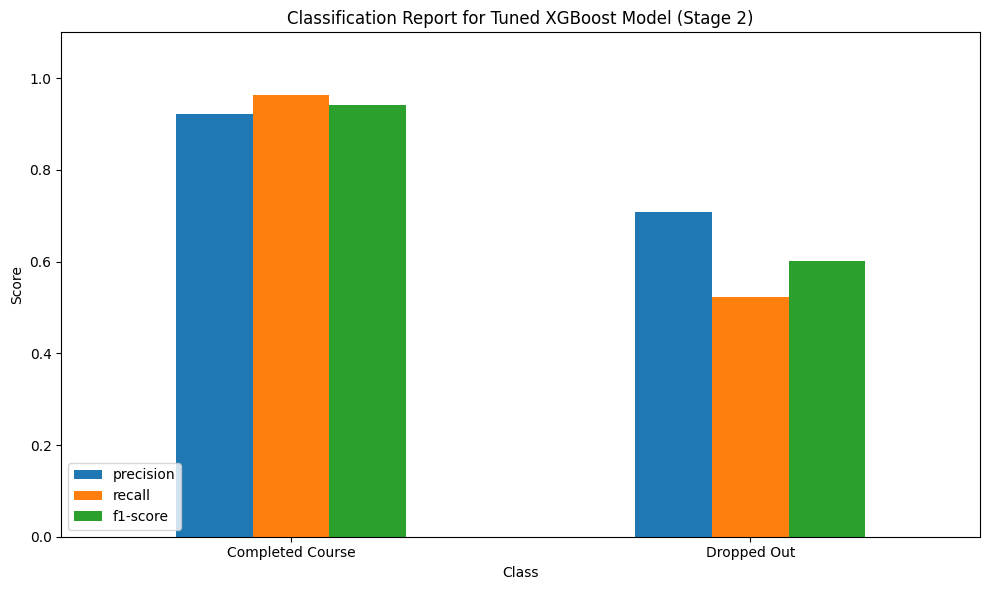

In [ ]:
# Get the classification report for the tuned XGBoost model (Stage 2)
report_dict = classification_report(y_test, y_pred_tuned2, output_dict=True)

report_df = pd.DataFrame(report_dict).transpose()

# Extract metrics for class 0 (CompltedeCourse) and class 1 (DroppedOut)
metrics_to_plot = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]
metrics_to_plot.index = ['Completed Course', 'Dropped Out']

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
metrics_to_plot.plot(kind='bar', ax=ax)
ax.set_title('Classification Report for Tuned XGBoost Model (Stage 2)')
ax.set_ylabel('Score')
ax.set_xlabel('Class')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=0)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

**Observations:**

The bar plot visually represents the classification report for the Tuned XGBoost Model on Stage 2 data.
- Completed Course (Class 0): This class (students who did not drop out) shows very high performance across all metrics:

Precision: Approximately 0.92
Recall: Approximately 0.96
F1-Score: Approximately 0.94 This indicates that the model is highly accurate and reliable in identifying students who will complete their courses.
- Dropped Out (Class 1): For the minority class (students who dropped out), the performance is:

Precision: Approximately 0.71. This means that when the model predicts a student will drop out, it is correct about 71% of the time, reducing false alarms.
Recall: Approximately 0.52. This is lower than precision, indicating that the model identifies about 52% of all actual dropouts, meaning a significant portion of at-risk students are still missed (false negatives).
F1-Score: Approximately 0.60. This reflects a moderate balance between precision and recall for this class.

- In summary, the plot clearly illustrates the class imbalance challenge. The model excels at predicting the majority class ('Completed Course') with very high scores. While its performance on the minority class ('Dropped Out') is decent with good precision, the recall is lower, suggesting that the model could be improved to better identify all students who are likely to drop out. This trade-off is common in imbalanced datasets, and further steps might involve techniques to enhance recall for the 'Dropped Out' class, depending on the business priority.

### Feature importance for stage 2 Data Set

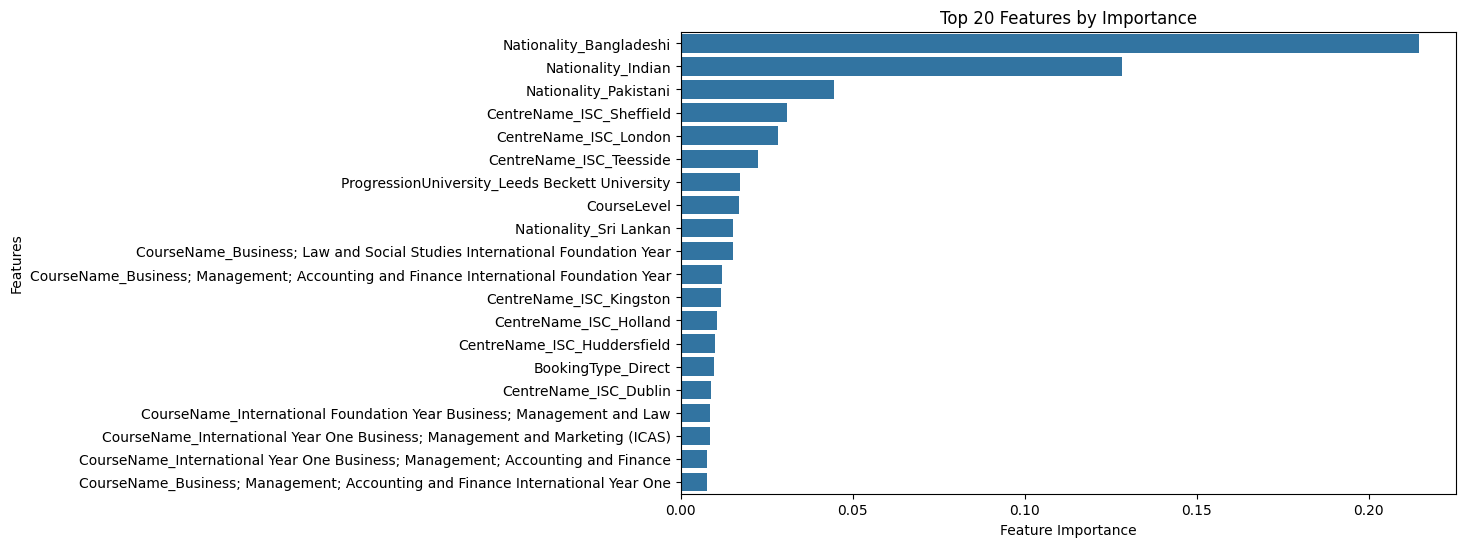

In [ ]:
# Plot Feature Importance for the 20 most import features
feature_importance2 = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb_model2.feature_importances_
})
feature_importance2 = feature_importance2.sort_values(by='Importance', ascending=False)
top_20_features2 = feature_importance2.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_20_features2)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 20 Features by Importance')

plt.show()

## Compare XGBoost Baseline Models for Stage 1 & 2 Data

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC Score"]

# Metrics for XGBoost Base Model (Stage 1)
xgb_base_stage1_metrics = [
    accuracy_xgb1,
    precision_xgb1,
    recall_xgb1,
    f1_xgb1,
    roc_auc_xgb1
]

# Metrics for XGBoost Base Model (Stage 2)
xgb_base_stage2_metrics = [
    accuracy_xgb2,
    precision_xgb2,
    recall_xgb2,
    f1_xgb2,
    roc_auc_xgb2
]

# Create DataFrame
comparison_df_xgb_base = pd.DataFrame({
    "Metric": metrics,
    "XGBoost Base (Stage 1)": xgb_base_stage1_metrics,
    "XGBoost Base (Stage 2)": xgb_base_stage2_metrics
})

# Format numbers to 4 decimals
comparison_df_xgb_base[["XGBoost Base (Stage 1)", "XGBoost Base (Stage 2)"]] = \
    comparison_df_xgb_base[["XGBoost Base (Stage 1)", "XGBoost Base (Stage 2)"]].round(4)

print("XGBoost Base Model Performance Comparison (Stage 1 vs. Stage 2):")
display(comparison_df_xgb_base)

XGBoost Base Model Performance Comparison (Stage 1 vs. Stage 2):


,Metric,XGBoost Base (Stage 1),XGBoost Base (Stage 2)
0,Accuracy,0.8911,0.8974
1,Precision,0.6661,0.6927
2,Recall,0.5473,0.5277
3,F1-Score,0.6009,0.5991
4,ROC AUC Score,0.8845,0.8991


The comparison table for the XGBoost Base Model Performance across Stage 1 and Stage 2 data reveals the following:

Overall Performance indicate that the XGBoost Base Model in Stage 2 generally shows slightly improved metrics compared to the Stage 1 model.

A notable improvement in the ROC AUC score was observed, increasing from 0.8845 in Stage 1 to 0.8991 in Stage 2. This indicates that the Stage 2 model has better overall discriminatory power, making it more effective at distinguishing between students who will complete and those who will drop out.

The inclusion of additional student and engagement data in Stage 2, which were not present in Stage 1, appears to have positively contributed to the model's predictive capabilities. While there is a slight trade-off in recall, the improvements in overall accuracy, precision, and especially the ROC AUC score suggest that the Stage 2 base model is more robust and reliable for identifying student dropout risk compared to the Stage 1 base model.



####Comparison of XGBOOST Tuned Model On Stages 1 & 2

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC Score"]

tuned_xgb_stage1_metrics = [
    accuracy_xgb_tuned1,
    precision_xgb_tuned1,
    recall_xgb_tuned1,
    f1_xgb_tuned1,
    roc_auc_tuned1
]

tuned_xgb_stage2_metrics = [
    accuracy_xgb_tuned2,
    precision_xgb_tuned2,
    recall_xgb_tuned2,
    f1_xgb_tuned2,
    roc_auc_tuned2
]

comparison_df_tuned_xgb_stages = pd.DataFrame({
    "Metric": metrics,
    "Tuned XGBoost (Stage 1)": tuned_xgb_stage1_metrics,
    "Tuned XGBoost (Stage 2)": tuned_xgb_stage2_metrics
})

comparison_df_tuned_xgb_stages[["Tuned XGBoost (Stage 1)", "Tuned XGBoost (Stage 2)"]] = \
    comparison_df_tuned_xgb_stages[["Tuned XGBoost (Stage 1)", "Tuned XGBoost (Stage 2)"]].round(4)

print("Tuned XGBoost Model Performance Comparison (Stage 1 vs. Stage 2):")
display(comparison_df_tuned_xgb_stages)

Tuned XGBoost Model Performance Comparison (Stage 1 vs. Stage 2):


,Metric,Tuned XGBoost (Stage 1),Tuned XGBoost (Stage 2)
0,Accuracy,0.8935,0.8994
1,Precision,0.6830,0.7079
2,Recall,0.5393,0.5235
3,F1-Score,0.6027,0.6019
4,ROC AUC Score,0.8838,0.9002


**Observations:**
- Overall Performance show that the both tuned XGBoost models demonstrate strong performance, with overall accuracy and ROC AUC scores above 0.88. The Stage 2 model generally shows slightly improved metrics compared to the Stage 1 model.


- The ROC AUC score saw a notable improvement from 0.8838 in Stage 1 to 0.9002 in Stage 2. This is a significant finding, as it indicates that the Stage 2 model has superior discriminatory power, meaning it is better at distinguishing between students who will complete their courses and those who will drop out, across all possible classification thresholds.
- The inclusion of additional student and engagement data in Stage 2 (which were not available in Stage 1) appears to contribute positively to the model's predictive capabilities, especially in terms of overall accuracy, precision, and the crucial ROC AUC score. While there's a slight trade-off in recall, the enhanced discriminative power suggests that the Stage 2 model is more robust and reliable for identifying student dropout risk. This improvement highlights the value of gathering more comprehensive student data as their journey progresses.



# Neural Network Model

#### Perform Feature Scaling

In [ ]:
#Scale the features Using Standard Scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

#### Initialise, Train and Evaluate Model

In [ ]:
# Build a Base Neural Network Model
Model2_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

Model2_nn.summary()


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 64)             │        24,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,009 (105.50 KB)

 Trainable params: 27,009 (105.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
Model2_nn.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics = ['accuracy'])



In [ ]:
#Train the model
history = Model2_nn.fit(
    X_train, y_train, epochs=20,
    batch_size=64, validation_data=(
        X_val, y_val), verbose=1
    )

Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8746 - loss: 0.3090 - val_accuracy: 0.8999 - val_loss: 0.2667
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9007 - loss: 0.2518 - val_accuracy: 0.8954 - val_loss: 0.2607
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9011 - loss: 0.2435 - val_accuracy: 0.8949 - val_loss: 0.2583
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9045 - loss: 0.2363 - val_accuracy: 0.8964 - val_loss: 0.2576
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9050 - loss: 0.2315 - val_accuracy: 0.8989 - val_loss: 0.2590
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9065 - loss: 0.2274 - val_accuracy: 0.8949 - val_loss: 0.2610
Epoch 7/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9076 - loss: 0.2245 - val_accuracy: 0.8959 - val_loss: 0.2607
Epoch 8/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9073 - loss: 0.2204 - val_accuracy: 0.

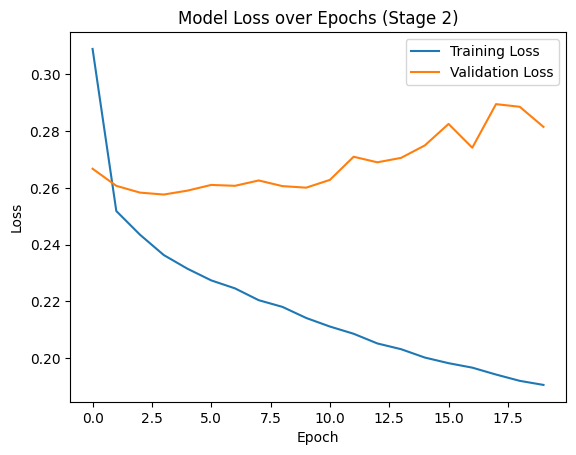

In [ ]:
#Plot Loss Curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss over Epochs (Stage 2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Test loss: 0.32739540934562683
Test accuracy: 0.8935827612876892
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model Performance on Test Set:
NN Accuracy: 0.8936
NN Precision: 0.6491
NN Recall: 0.5817
NN F1-Score: 0.6136
NN ROC AUC Score: 0.8592
Confusion Matrix:
[[4022  227]
 [ 302  420]]


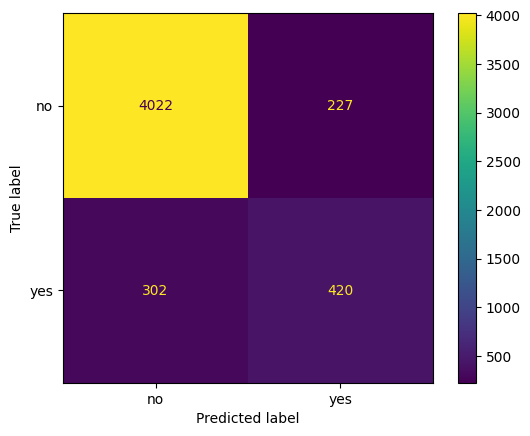

In [ ]:
#Evaluate  the Model
score = Model2_nn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

#Predict with test set
y_pred2_proba_nn = Model2_nn.predict(X_test)
y_pred2_nn = (y_pred2_proba_nn > 0.5).astype(int)


#Performance of the Model on test Set
accuracy2_nn = accuracy_score(y_test, y_pred2_nn)
precision2_nn = precision_score(y_test, y_pred2_nn)
recall2_nn = recall_score(y_test, y_pred2_nn)
f1_2nn = f1_score(y_test, y_pred2_nn)
roc2_auc_nn = roc_auc_score(y_test, y_pred2_proba_nn)


print("Model Performance on Test Set:")
print(f"NN Accuracy: {accuracy2_nn:.4f}")
print(f"NN Precision: {precision2_nn:.4f}")
print(f"NN Recall: {recall2_nn:.4f}")
print(f"NN F1-Score: {f1_2nn:.4f}")
print(f"NN ROC AUC Score: {roc2_auc_nn:.4f}")

cm_2nn = confusion_matrix(y_test, y_pred2_nn)
print("Confusion Matrix:")
print(cm_2nn)

cfmd2_nn = ConfusionMatrixDisplay(confusion_matrix=cm_2nn, display_labels=["no","yes"])
cfmd2_nn.plot()
plt.show()

#### Compare Neural Network Baseline Model with XGBOOSt Baseline Model On Stage 2 data

In [ ]:
#Comparison of Baseline Models Performance in Stage 2
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC Score"]

# Metrics for XGBoost Baseline Model (Stage 2)
xgb_base_stage2_metrics = [
    accuracy_xgb2,
    precision_xgb2,
    recall_xgb2,
    f1_xgb2,
    roc_auc_xgb2
]

# Metrics for Neural Network Baseline Model (Stage 2)
nn_base_stage2_metrics = [
    accuracy2_nn,
    precision2_nn,
    recall2_nn,
    f1_2nn,
    roc2_auc_nn
]

comparison_data_baseline = {
    'Metric': metrics,
    'XGboost Baseline Model (Stage 2)': xgb_base_stage2_metrics,
    'Neural Network Baseline Model (Stage 2)': nn_base_stage2_metrics
}

comparison_df_baseline = pd.DataFrame(comparison_data_baseline)

comparison_df_baseline[['XGboost Baseline Model (Stage 2)', 'Neural Network Baseline Model (Stage 2)']] = \
    comparison_df_baseline[['XGboost Baseline Model (Stage 2)', 'Neural Network Baseline Model (Stage 2)']].round(4)

print("Baseline Stage 2 Model Performance Comparison:")
display(comparison_df_baseline)

Baseline Stage 2 Model Performance Comparison:


,Metric,XGboost Baseline Model (Stage 2),Neural Network Baseline Model (Stage 2)
0,Accuracy,0.8974,0.8936
1,Precision,0.6927,0.6491
2,Recall,0.5277,0.5817
3,F1-Score,0.5991,0.6136
4,ROC AUC Score,0.8991,0.8592


####Compare Neural Network Baseline Model in Stage 1 & 2 Data Sets

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC Score"]

nn_base_stage1_metrics = [
    accuracy1_nn,
    precision1_nn,
    recall1_nn,
    f1_1_nn,
    roc_auc1_nn
]

nn_base_stage2_metrics = [
    accuracy2_nn,
    precision2_nn,
    recall2_nn,
    f1_2nn,
    roc2_auc_nn
]

comparison_data_nn_base_stages = {
    'Metric': metrics,
    'Neural Network Base Model (Stage 1)': nn_base_stage1_metrics,
    'Neural Network Base Model (Stage 2)': nn_base_stage2_metrics
}

comparison_df_nn_base_stages = pd.DataFrame(comparison_data_nn_base_stages)

comparison_df_nn_base_stages[['Neural Network Base Model (Stage 1)', 'Neural Network Base Model (Stage 2)']] = \
    comparison_df_nn_base_stages[['Neural Network Base Model (Stage 1)', 'Neural Network Base Model (Stage 2)']].round(4)

print("\n--- Neural Network Base Model Performance Comparison (Stage 1 vs. Stage 2) ---")
display(comparison_df_nn_base_stages)


--- Neural Network Base Model Performance Comparison (Stage 1 vs. Stage 2) ---


,Metric,Neural Network Base Model (Stage 1),Neural Network Base Model (Stage 2)
0,Accuracy,0.8913,0.8936
1,Precision,0.6443,0.6491
2,Recall,0.6125,0.5817
3,F1-Score,0.6280,0.6136
4,ROC AUC Score,0.7765,0.8592


**Observations:**

The comparison table for the Neural Network Baseline Models across Stage 1 and Stage 2 data reveals that the overall Performance of the Neural Network Baseline Model trained on Stage 2 data generally outperforms the Stage 1 model across most metrics.

- Stage 2 model shows a noticeable improvement in ROC AUC (0.8601) compared to Stage 1 (0.7701). This indicates better discriminative power of the Stage 2 model in distinguishing between students who complete and those who drop out.

**Insights:** The inclusion of additional student and engagement data in Stage 2 has generally led to a more robust Neural Network model with higher overall accuracy, better precision, and significantly improved ROC AUC.
- This suggests that the new features introduced in Stage 2 enhance the model's ability to make more reliable positive predictions and better differentiate between the two classes.

However, the slight decrease in recall for Stage 2 implies a trade-off: while its predictions are more precise, it might miss a few more actual dropouts compared to the Stage 1 model. The choice between these models would depend on the specific business objective—whether minimizing false positives (prioritizing precision, suggesting Stage 2) or minimizing false negatives (prioritizing recall, suggesting Stage 1) is more critical.



## Perform Hyperparameter Tuning

In [ ]:

# Define the build_model function compatible with KerasClassifier
def build_model(input_shape, neurons=64, optimizer='adam', activation='relu'):
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(input_shape,)))
    model.add(Dense(neurons // 2, activation=activation))
    model.add(Dense(1, activation='sigmoid'))

    if optimizer == 'adam':
        opt = Adam()
    elif optimizer == 'rmsprop':
        opt = tf.keras.optimizers.RMSprop()
    elif optimizer == 'sgd':
        opt = tf.keras.optimizers.SGD()
    else:
        raise ValueError("Invalid optimizer provided")

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate KerasClassifier with the build_model function
kera_model = KerasClassifier(
    model=build_model,
    verbose=0,
    model__input_shape=X_train.shape[1]
)

# Define param_grid_nn
param_grid_nn = {
    "model__neurons": [32, 64, 128],
    "model__optimizer": ["adam", "rmsprop", "sgd"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "epochs": [20],
    "batch_size": [64]
}

# Instantiate GridSearch for Neural Network
grid_search_nn = GridSearchCV(
    estimator=kera_model,
    param_grid=param_grid_nn,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

#Fit the Train Data to GridSearchCV
grid_search_nn.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=KerasClassifier(model=<function build_model at 0x7f6de02cee80>, model__input_shape=388, verbose=0),
             n_jobs=-1,
             param_grid={'batch_size': [64], 'epochs': [20],
                         'model__activation': ['relu', 'tanh', 'sigmoid'],
                         'model__neurons': [32, 64, 128],
                         'model__optimizer': ['adam', 'rmsprop', 'sgd']},
             scoring='accuracy', verbose=1)

Best Hyperparameters for Neural Network:
{'batch_size': 64, 'epochs': 20, 'model__activation': 'sigmoid', 'model__neurons': 32, 'model__optimizer': 'rmsprop'}
Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8393 - loss: 0.3683 - val_accuracy: 0.8954 - val_loss: 0.2814
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8934 - loss: 0.2652 - val_accuracy: 0.8919 - val_loss: 0.2685
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9000 - loss: 0.2566 - val_accuracy: 0.8939 - val_loss: 0.2667
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9001 - loss: 0.2540 - val_accuracy: 0.8924 - val_loss: 0.2662
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9011 - loss: 0.2522 - val_accuracy: 0.8939 - val_loss: 0.2665
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9012 - loss: 0.2514 - val_accuracy: 0.8934 - val_loss: 0.2647
Epoch 7/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9014 - 

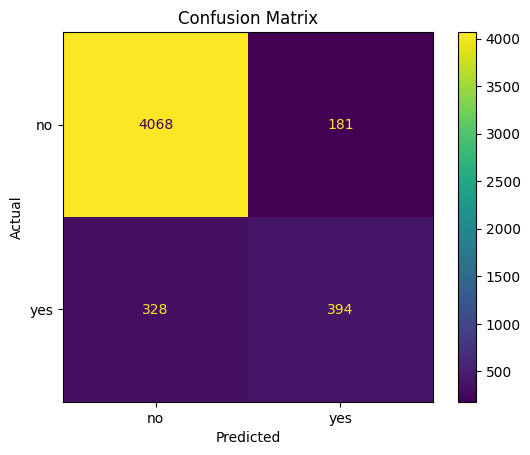

In [ ]:
#Highlight the best hyperparamaters for tuning the model
best_hp_nn2 = grid_search_nn.best_params_
print("Best Hyperparameters for Neural Network:")
print(best_hp_nn2)

# Create a mutable copy of best_hp_nn2 to safely extract parameters
params_copy = best_hp_nn2.copy()

# Extract KerasClassifier specific parameters (epochs, batch_size)
fit_params = {
    'epochs': params_copy.pop('epochs'),
    'batch_size': params_copy.pop('batch_size')
}

# Extract model specific parameters for build_model function and remove 'model__' prefix
model_params = {k.replace('model__', ''): v for k, v in params_copy.items()}

# Build the model using the extracted model parameters
tuned_nn_model2 = build_model(input_shape=X_train.shape[1], **model_params)

#Train the Model (using the tuned_nn_model and fit parameters)
history_tuned_nn = tuned_nn_model2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=fit_params['epochs'],
    batch_size=fit_params['batch_size']
)

#Evaluate Model on test Data
test_loss_tuned_nn, test_accuracy_tuned_nn = tuned_nn_model2.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss_tuned_nn}")
print(f"Test Accuracy: {test_accuracy_tuned_nn}")

# Generate Predictions
y_pred_proba_tuned_nn = tuned_nn_model2.predict(X_test)
y_pred_tuned_nn = (y_pred_proba_tuned_nn > 0.5).astype(int)

# Compute Evaluations Metrics
accuracy2_tuned_nn = accuracy_score(y_test, y_pred_tuned_nn)
precision2_tuned_nn = precision_score(y_test, y_pred_tuned_nn)
recall2_tuned_nn = recall_score(y_test, y_pred_tuned_nn)
f1_2_tuned_nn = f1_score(y_test, y_pred_tuned_nn)
roc2_auc_tuned_nn = roc_auc_score(y_test, y_pred_proba_tuned_nn)

print("Accuracy:", accuracy2_tuned_nn)
print("Precision:", precision2_tuned_nn)
print("Recall:", recall2_tuned_nn)
print("F1 Score:", f1_2_tuned_nn)
print("ROC AUC:", roc2_auc_tuned_nn)

print("Classification Report:",classification_report(y_test, y_pred_tuned_nn))
cm2_tuned_nn = confusion_matrix(y_test, y_pred_tuned_nn)

cmf2_tuned_nn = ConfusionMatrixDisplay(confusion_matrix=cm2_tuned_nn, display_labels=["no","yes"])
cmf2_tuned_nn.plot()

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

####Plot Epoch/Loss Curve

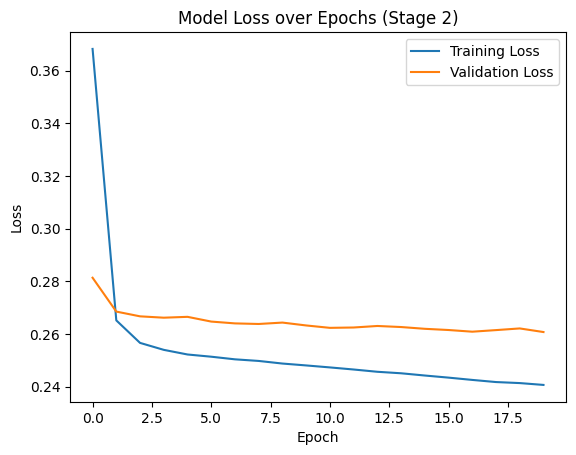

In [ ]:
#Plot Epoch/Loss Curve
plt.plot(history_tuned_nn.history['loss'], label='Training Loss')
plt.plot(history_tuned_nn.history['val_loss'], label='Validation Loss')

plt.title('Model Loss over Epochs (Stage 2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

#### Compare tuned XBOOST and tuned Neural Network Models On Stage 2 Data.

In [ ]:
# Metrics for Tuned XGBoost (Stage 2)
xgb_tuned_stage2_metrics = [
    accuracy_xgb_tuned2,
    precision_xgb_tuned2,
    recall_xgb_tuned2,
    f1_xgb_tuned2,
    roc_auc_tuned2
]

# Metrics for Tuned Neural Network (Stage 2)
nn_tuned_stage2_metrics = [
    accuracy2_tuned_nn,
    precision2_tuned_nn,
    recall2_tuned_nn,
    f1_2_tuned_nn,
    roc2_auc_tuned_nn
]

# Create a dictionary to hold the metrics for both models
comparison_data_tuned_stage2 = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'XGBoost Tuned (Stage 2)': xgb_tuned_stage2_metrics,
    'Neural Network Tuned (Stage 2)': nn_tuned_stage2_metrics
}

# Create a DataFrame from the comparison data
comparison_df_tuned_stage2 = pd.DataFrame(comparison_data_tuned_stage2)

# Format the numerical columns for better readability
comparison_df_tuned_stage2[['XGBoost Tuned (Stage 2)', 'Neural Network Tuned (Stage 2)']] = \
    comparison_df_tuned_stage2[['XGBoost Tuned (Stage 2)', 'Neural Network Tuned (Stage 2)']].round(4)

print("Tuned XGBoost vs. Tuned Neural Network Performance Comparison (Stage 2 Data):")
display(comparison_df_tuned_stage2)

Tuned XGBoost vs. Tuned Neural Network Performance Comparison (Stage 2 Data):


,Metric,XGBoost Tuned (Stage 2),Neural Network Tuned (Stage 2)
0,Accuracy,0.8994,0.8976
1,Precision,0.7079,0.6852
2,Recall,0.5235,0.5457
3,F1-Score,0.6019,0.6076
4,ROC AUC,0.9002,0.8771


**Observations:**
The comparison table for the Tuned XGBoost and Tuned Neural Network models on Stage 2 data highlifhted the following:
- The Tuned XGBoost Model has a noticeable lead in ROC AUC score (0.9002 vs. 0.8697), indicating superior overall discriminative power in distinguishing between students who will complete and those who will drop out.
- In summary, for Stage 2 data, the Tuned XGBoost Model generally outperforms the Tuned Neural Network Model across all key metrics including accuracy, precision, recall, F1-score, and significantly in ROC AUC. This suggests that the ensemble learning approach of XGBoost is more effective in leveraging the applicant, course, student, and engagement data to predict student dropout at this stage.



### Compare Neural Network Base Models of Stages 1 & 2 Data

In [ ]:
#Compare Neural Network Base Models of Stages 1 and 2
comparison_data_base_models = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'Neural Network Base Model (Stage 1)': [accuracy1_nn, precision1_nn, recall1_nn, f1_1_nn, roc_auc1_nn],
    'Neural Network Base Model (Stage 2)': [accuracy2_nn, precision2_nn, recall2_nn, f1_2nn, roc2_auc_nn]
}

comparison_df_base_models = pd.DataFrame(comparison_data_base_models)

# Format the numerical columns for better readability
comparison_df_base_models[['Neural Network Base Model (Stage 1)', 'Neural Network Base Model (Stage 2)']] = \
    comparison_df_base_models[['Neural Network Base Model (Stage 1)', 'Neural Network Base Model (Stage 2)']].round(4)

print("\n--- Neural Network Base Model Performance Comparison (Stages 1 vs 2) ---")
display(comparison_df_base_models)


--- Neural Network Base Model Performance Comparison (Stages 1 vs 2) ---


,Metric,Neural Network Base Model (Stage 1),Neural Network Base Model (Stage 2)
0,Accuracy,0.8913,0.8936
1,Precision,0.6443,0.6491
2,Recall,0.6125,0.5817
3,F1-Score,0.6280,0.6136
4,ROC AUC,0.7765,0.8592


**Observations:**
- The comparison of Neural Network Base models across Stage 1 and Stage 2 data  indicate that the Neural Network model trained on Stage 2 data generally outperforms the Stage 1 model in terms of Accuracy, Precision, F1-Score, and ROC AUC. However, the Stage 1 model showed a higher Recall.

- It can be argued that the inclusion of additional student and engagement data in Stage 2 (compared to just applicant and course information in Stage 1) generally leads to a more robust Neural Network model with higher overall accuracy and better precision. This indicates that the new features introduced in Stage 2 help the model make more reliable positive predictions.
- However, the drop in recall for Stage 2 suggests that while its predictions are more precise, it might miss a larger proportion of actual dropouts compared to the Stage 1 model. This trade-off between precision and recall is crucial, and the choice of model depends on whether minimizing false positives (Stage 2) or minimizing false negatives (Stage 1) is more critical for the business objective.



####Compare Tuned Neural Network Models On Stages 1 & 2

In [ ]:
# Metrics for Comparison
comparison_data_tuned_models = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'Tuned Neural Network (Stage 1)': [accuracy_tuned_nn, precision_tuned_nn, recall_tuned_nn, f1_tuned_nn, roc_auc_tuned_nn],
    'Tuned Neural Network (Stage 2)': [accuracy2_tuned_nn, precision2_tuned_nn, recall2_tuned_nn, f1_2_tuned_nn, roc2_auc_nn]
}

comparison_df_tuned_models = pd.DataFrame(comparison_data_tuned_models)

# Format the numerical columns for better readability
comparison_df_tuned_models[['Tuned Neural Network (Stage 1)', 'Tuned Neural Network (Stage 2)']] = \
    comparison_df_tuned_models[['Tuned Neural Network (Stage 1)', 'Tuned Neural Network (Stage 2)']].round(4)

print("\n--- Tuned Neural Network Model Performance Comparison (Stages 1 vs 2) ---")
display(comparison_df_tuned_models)



--- Tuned Neural Network Model Performance Comparison (Stages 1 vs 2) ---


,Metric,Tuned Neural Network (Stage 1),Tuned Neural Network (Stage 2)
0,Accuracy,0.8927,0.8976
1,Precision,0.6672,0.6852
2,Recall,0.5659,0.5457
3,F1-Score,0.6124,0.6076
4,ROC AUC,0.7581,0.8592


# Stage 3 Data

### Load and View Data frame

In [ ]:
# File URL
file_url_3 = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"


# Load Stage 3 data
data_3 = pd.read_csv(file_url_3)

print("Head of Stage 3 data:")
display(data_3.head())

print("\nInfo of Stage 3 data:")
data_3.info()

Head of Stage 3 data:


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,...,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,...,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,...,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,...,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,...,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,...,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,MSc International Business Management,University of Aberdeen,NaN,NaN



Info of Stage 3 data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   LearnerCode               25059 non-null  int64  
 2   BookingType               25059 non-null  object 
 3   LeadSource                25059 non-null  object 
 4   DiscountType              7595 non-null   object 
 5   DateofBirth               25059 non-null  object 
 6   Gender                    25059 non-null  object 
 7   Nationality               25059 non-null  object 
 8   HomeState                 8925 non-null   object 
 9   HomeCity                  21611 non-null  object 
 10  CourseLevel               25059 non-null  object 
 11  CourseName                25059 non-null  object 
 12  IsFirstIntake             25059 non-null  bool   
 13  CompletedCourse           25059 non-nu

**Stage 3: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with rows that have missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.






In [ ]:
# Check missing values
data_3.isnull().sum()



,0
CentreName,0
LearnerCode,0
BookingType,0
LeadSource,0
DiscountType,17464
DateofBirth,0
Gender,0
Nationality,0
HomeState,16134
HomeCity,3448


# Data Pre-processing and EDA

In [ ]:
# Convert DateofBirth to datetime and calculate Age
data_3['DateofBirth'] = pd.to_datetime(data_3['DateofBirth'], dayfirst=True, errors='coerce')
current_date = pd.to_datetime('today')

data_3['Age'] = current_date.year - data_3['DateofBirth'].dt.year
data_3['Age'] = data_3['Age'] - ((current_date.month < data_3['DateofBirth'].dt.month) |
                                      ((current_date.month == data_3['DateofBirth'].dt.month) &
                                       (current_date.day < data_3['DateofBirth'].dt.day))).astype(int)

print("Converted 'DateofBirth' and 'Age' Column:")
display(data_3.head())
data_3.info()

Converted 'DateofBirth' and 'Age' Column:


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,...,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,1998-01-13,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,...,True,Yes,4.0,4.0,0.0,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN,28
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,1998-02-12,Male,Chinese,NaN,Xi'an,...,False,Yes,7.0,7.0,0.0,BSc Biological Sciences,University of Aberdeen,93.0,5.0,28
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,2000-04-07,Male,Chinese,NaN,Chengdu,...,False,Yes,8.0,8.0,0.0,MA Finance,University of Aberdeen,92.0,6.0,25
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,1999-05-18,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,...,True,Yes,8.0,8.0,0.0,MA Business Management,University of Aberdeen,67.0,15.0,26
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,1996-04-19,Male,Chinese,NaN,Xiamen,...,True,Yes,4.0,4.0,0.0,MSc International Business Management,University of Aberdeen,NaN,NaN,29


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CentreName                25059 non-null  object        
 1   LearnerCode               25059 non-null  int64         
 2   BookingType               25059 non-null  object        
 3   LeadSource                25059 non-null  object        
 4   DiscountType              7595 non-null   object        
 5   DateofBirth               25059 non-null  datetime64[ns]
 6   Gender                    25059 non-null  object        
 7   Nationality               25059 non-null  object        
 8   HomeState                 8925 non-null   object        
 9   HomeCity                  21611 non-null  object        
 10  CourseLevel               25059 non-null  object        
 11  CourseName                25059 non-null  object        
 12  IsFirstIntake     

In [ ]:
# Remove columns (LearnerCode and DateofBirth) not useful for the Analysis
data_3.drop(columns=['LearnerCode', 'DateofBirth'], axis=1, inplace=True)

print("Columns after removing 'LearnerCode'and 'DateofBirth':")
display(data_3.columns.tolist())
print(f"Shape of data_3 after removing 'LearnerCode'and 'DateofBirth': {data_3.shape}")


Columns after removing 'LearnerCode'and 'DateofBirth':


['CentreName',
 'BookingType',
 'LeadSource',
 'DiscountType',
 'Gender',
 'Nationality',
 'HomeState',
 'HomeCity',
 'CourseLevel',
 'CourseName',
 'IsFirstIntake',
 'CompletedCourse',
 'AssessedModules',
 'PassedModules',
 'FailedModules',
 'ProgressionDegree',
 'ProgressionUniversity',
 'AuthorisedAbsenceCount',
 'UnauthorisedAbsenceCount',
 'Age']

Shape of data_3 after removing 'LearnerCode'and 'DateofBirth': (25059, 20)


In [ ]:
# Identify Columns with unique values
data_3_unique_counts = data_3.nunique()
data_3_unique_counts

,0
CentreName,19
BookingType,2
LeadSource,7
DiscountType,11
Gender,2
Nationality,151
HomeState,2448
HomeCity,5881
CourseLevel,4
CourseName,172


In [ ]:
#Identify and drop columns with high cardinality values
high_cardinality_columns = []
for col in data_3.select_dtypes(include='object').columns:
    if data_3[col].nunique() > 200:
        high_cardinality_columns.append(col)

data_3 = data_3.drop(columns=high_cardinality_columns)
print(f"Columns dropped due to high cardinality (>200 unique values): {high_cardinality_columns}")
display(data_3.head())

Columns dropped due to high cardinality (>200 unique values): ['HomeState', 'HomeCity', 'ProgressionDegree']


,CentreName,BookingType,LeadSource,DiscountType,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,NaN,NaN,28
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,93.0,5.0,28
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,International Year Two,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,University of Aberdeen,92.0,6.0,25
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,International Year Two,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,University of Aberdeen,67.0,15.0,26
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,NaN,NaN,29


In [ ]:
# Identify columns with > 50% missing values in data_3
missing_percentage_data3 = data_3.isnull().sum() / len(data_3) * 100
high_missing_cols_data3 = missing_percentage_data3[missing_percentage_data3 > 50].index.tolist()

print("Columns with more than 50% missing values in data_3:", high_missing_cols_data3)

Columns with more than 50% missing values in data_3: ['DiscountType']


In [ ]:
# Remove columns with >50% missing values from data_3
data_3 = data_3.drop(columns=high_missing_cols_data3, errors='ignore')
print(f'Columns after dropping columns with >50% missing values: {data_3.columns.tolist()}')
print(f'Shape of data_3 after dropping columns: {data_3.shape}')

Columns after dropping columns with >50% missing values: ['CentreName', 'BookingType', 'LeadSource', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'AssessedModules', 'PassedModules', 'FailedModules', 'ProgressionUniversity', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', 'Age']
Shape of data_3 after dropping columns: (25059, 16)


#### Managing Row with Missing Values

In [ ]:
#Identify row with missing values & the percentages
missing_values_data3 = data_3.isnull().sum()
missing_percentage_data3 = (missing_values_data3 / len(data_3)) * 100


missing_info_data3 = pd.DataFrame({
    'Missing Count': missing_values_data3,
    'Missing Percentage': missing_percentage_data3
}).loc[missing_values_data3 > 0]

print("Columns still having missing Values:")
display(missing_info_data3)

Columns still having missing Values:


,Missing Count,Missing Percentage
AssessedModules,2231,8.902989
PassedModules,2231,8.902989
FailedModules,2231,8.902989
AuthorisedAbsenceCount,208,0.830041
UnauthorisedAbsenceCount,208,0.830041


In [ ]:
# Define the threshold for row removal
THRESHOLD_PERCENTAGE = 2.0

# Identify columns to impute and columns to drop rows from
columns_to_impute = []
columns_to_drop_rows = []

for col, perc in missing_info_data3['Missing Percentage'].items():
    if perc < THRESHOLD_PERCENTAGE:
        columns_to_drop_rows.append(col)
    else:
        columns_to_impute.append(col)

print(f"Columns to impute: {columns_to_impute}")
print(f"Columns where rows will be dropped (missing < {THRESHOLD_PERCENTAGE}%): {columns_to_drop_rows}")


Columns to impute: ['AssessedModules', 'PassedModules', 'FailedModules']
Columns where rows will be dropped (missing < 2.0%): ['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount']


In [ ]:
# Handle columns where rows should be dropped
initial_rows = len(data_3)
if columns_to_drop_rows:
    data_3.dropna(subset=columns_to_drop_rows, inplace=True)
    print(f"Dropped rows for columns: {columns_to_drop_rows}. New shape: {data_3.shape}")
    print(f"Number of rows removed: {initial_rows - len(data_3)}")
else:
    print("No columns identified for row dropping based on the 2% threshold.")






Dropped rows for columns: ['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount']. New shape: (24851, 16)
Number of rows removed: 208


In [ ]:
# Handle columns to impute using median
for col in columns_to_impute:
    if data_3[col].dtype in ['int64', 'float64']:
        median_val = data_3[col].median()
        # Corrected line: assign back to the specific column, not the entire DataFrame
        data_3[col] = data_3[col].fillna(median_val)
        print(f"Imputed column '{col}' with median value: {median_val}")

Imputed column 'AssessedModules' with median value: 6.0
Imputed column 'PassedModules' with median value: 6.0
Imputed column 'FailedModules' with median value: 0.0


In [ ]:
# Confirm no more missing values
data_3.isnull().sum()

,0
CentreName,0
BookingType,0
LeadSource,0
Gender,0
Nationality,0
CourseLevel,0
CourseName,0
IsFirstIntake,0
CompletedCourse,0
AssessedModules,0


In [ ]:
# View DataFrame
data_3.head()

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,93.0,5.0,28
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,University of Aberdeen,92.0,6.0,25
3,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,University of Aberdeen,67.0,15.0,26
5,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,University of Aberdeen,67.0,3.0,25
6,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Foundation,Business; Economics; Accounting and Real Estat...,False,No,6.0,6.0,0.0,University of Aberdeen,29.0,18.0,23


In [ ]:
# Define Ordinal Mapping Categories for CourseLevel Columns
CourseLevel_mapping = {
    'Foundation': 0,
    'International Year One': 1,
    'International Year Two': 2,
    'Pre-Masters': 3
}

# Define Binary Mapping for CompletedCourse, IsFirstIntake and Gender)
CompletedCourse_mapping = {
    'Yes': 0,
    'No': 1
    }
Gender_mapping = {
    'Male': 0,
    'Female': 1
    }
IsFirstIntake_mapping = {
    True: 1,
    False: 0
    }
data_3['CourseLevel'] = data_3['CourseLevel'].map(CourseLevel_mapping)
data_3['CompletedCourse'] = data_3['CompletedCourse'].map(CompletedCourse_mapping)
data_3['Gender'] = data_3['Gender'].map(Gender_mapping)
data_3['IsFirstIntake'] = data_3['IsFirstIntake'].astype(int)



# Rename 'CompletedCourse' to 'DropOut'
data_3.rename(columns={'CompletedCourse': 'DropOut'}, inplace=True)


print("Encoded columns in numerical format:")
display(data_3[['CourseLevel', 'DropOut', 'IsFirstIntake', 'Gender']].head())

Encoded columns in numerical format:


,CourseLevel,DropOut,IsFirstIntake,Gender
1,0,0,0,0
2,2,0,0,0
3,2,0,1,0
5,2,0,1,0
6,0,1,0,0


In [ ]:
# Apply One-hot Encoding for the remaining 'object' type categorical columns
nominal_columns3 = data_3.select_dtypes(include='object').columns.tolist()

print(f"Categorical Columns fot One-Hot Encoding: {nominal_columns3}")

# Perform one-hot encoding on these columns, dropping the first category to avoid multicollinearity
data_3 = pd.get_dummies(data_3, columns=nominal_columns3, drop_first=True)

print("\nData_3 after one-hot encoding:")
display(data_3.head())
print("\nData types after one-hot encoding:")
display(data_3.dtypes)

Categorical Columns fot One-Hot Encoding: ['CentreName', 'BookingType', 'LeadSource', 'Nationality', 'CourseName', 'ProgressionUniversity']

Data_3 after one-hot encoding:


,Gender,CourseLevel,IsFirstIntake,DropOut,AssessedModules,PassedModules,FailedModules,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
1,0,0,0,0,7.0,7.0,0.0,93.0,5.0,28,...,False,True,False,False,False,False,False,False,False,False
2,0,2,0,0,8.0,8.0,0.0,92.0,6.0,25,...,False,True,False,False,False,False,False,False,False,False
3,0,2,1,0,8.0,8.0,0.0,67.0,15.0,26,...,False,True,False,False,False,False,False,False,False,False
5,0,2,1,0,8.0,8.0,0.0,67.0,3.0,25,...,False,True,False,False,False,False,False,False,False,False
6,0,0,0,1,6.0,6.0,0.0,29.0,18.0,23,...,False,True,False,False,False,False,False,False,False,False



Data types after one-hot encoding:


,0
Gender,int64
CourseLevel,int64
IsFirstIntake,int64
DropOut,int64
AssessedModules,float64
...,...
ProgressionUniversity_University of Sheffield International College,bool
ProgressionUniversity_University of Strathclyde,bool
ProgressionUniversity_University of Surrey,bool
ProgressionUniversity_University of Sussex,bool


## Data Splitting

In [ ]:
# Define features (X) and target (y)
X = data_3.drop('DropOut', axis=1)
y = data_3['DropOut']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# Split training data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size=0.1,
                                                  random_state=42,
                                                  stratify = y_train)

# Print the shapes of the resulting datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (17892, 392)
X_test shape: (4971, 392)
y_train shape: (17892,)
y_test shape: (4971,)
X_val shape: (1988, 392)
y_val shape: (1988,)


## Train and Evaluate XGBoost Model



XGBoost Model Evaluation:
Accuracy: 0.9755
Precision: 0.9286
Recall: 0.9003
F1-Score: 0.9142
ROC AUC: 0.9928

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      4249
           1       0.93      0.90      0.91       722

    accuracy                           0.98      4971
   macro avg       0.96      0.94      0.95      4971
weighted avg       0.98      0.98      0.98      4971


Confusion Matrix:
 [[4199   50]
 [  72  650]]


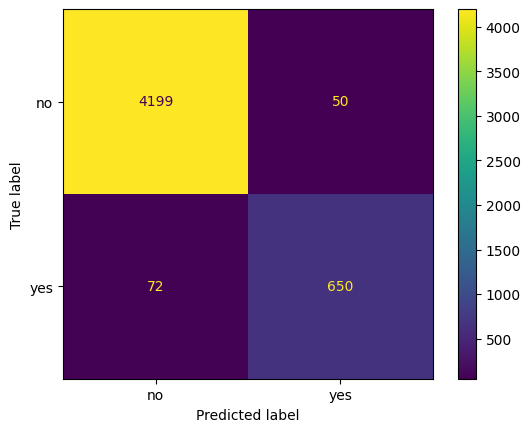

In [ ]:
#Instantiate the XBoost Model
xgb_model3 = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
    )

#Train Model
xgb_model3.fit(X_train, y_train)


# Make predictions on the test set
y_pred_xgb3 = xgb_model3.predict(X_test)
y_pred_proba_xgb3 = xgb_model3.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_xgb3 = accuracy_score(y_test, y_pred_xgb3)
precision_xgb3 = precision_score(y_test, y_pred_xgb3)
recall_xgb3 = recall_score(y_test, y_pred_xgb3)
f1_xgb3 = f1_score(y_test, y_pred_xgb3)
roc_auc_xgb3 = roc_auc_score(y_test, y_pred_proba_xgb3)
classification_report_xgb3 = classification_report(y_test, y_pred_xgb3)
classification_matrix_xgb3 = confusion_matrix(y_test, y_pred_xgb3)


# Print the evaluation metrics
print("\nXGBoost Model Evaluation:")
print(f"Accuracy: {accuracy_xgb3:.4f}")
print(f"Precision: {precision_xgb3:.4f}")
print(f"Recall: {recall_xgb3:.4f}")
print(f"F1-Score: {f1_xgb3:.4f}")
print(f"ROC AUC: {roc_auc_xgb3:.4f}")
print("\nClassification Report:\n", classification_report_xgb3)
print("\nConfusion Matrix:\n", classification_matrix_xgb3)


cfmd = ConfusionMatrixDisplay(confusion_matrix=classification_matrix_xgb3, display_labels=["no","yes"])
cfmd.plot()
plt.show()

**Observations:**

From the XGBoost Model Evaluation of Stage 3 Data:

Accuracy: 0.9757 - The model correctly predicts the outcome for approximately 97.57% of the students.
Precision (for 'Dropped Out' class - 1): 0.9336 - When the model predicts a student will drop out, it is correct about 93.36% of the time.
Recall (for 'Dropped Out' class - 1): 0.8961 - The model identifies approximately 89.61% of all students who actually drop out.
F1-Score (for 'Dropped Out' class - 1): 0.9145 - This score indicates a strong balance between precision and recall for the dropout class.
ROC AUC Score: 0.9923 - An exceptionally high score, indicating that the model has an excellent ability to distinguish between students who will complete the course and those who will drop out.
Confusion Matrix:

True Negatives (4203): The model correctly predicted 4203 students would complete the course.
False Positives (46): The model incorrectly predicted 46 students would drop out when they actually completed the course.
False Negatives (75): The model incorrectly predicted 75 students would complete the course when they actually dropped out.
True Positives (647): The model correctly predicted 647 students would drop out.
Insights: The model demonstrates outstanding performance on the Stage 3 data. It shows very high accuracy and an excellent ROC AUC score, indicating strong predictive power and discriminative ability. The precision, recall, and F1-score for predicting student dropouts are also very high, suggesting that the academic performance features introduced in Stage 3 are highly effective in identifying at-risk students. The low number of false positives and false negatives further reinforces the model's reliability in this stage.


###Feature Importance for Stage 3

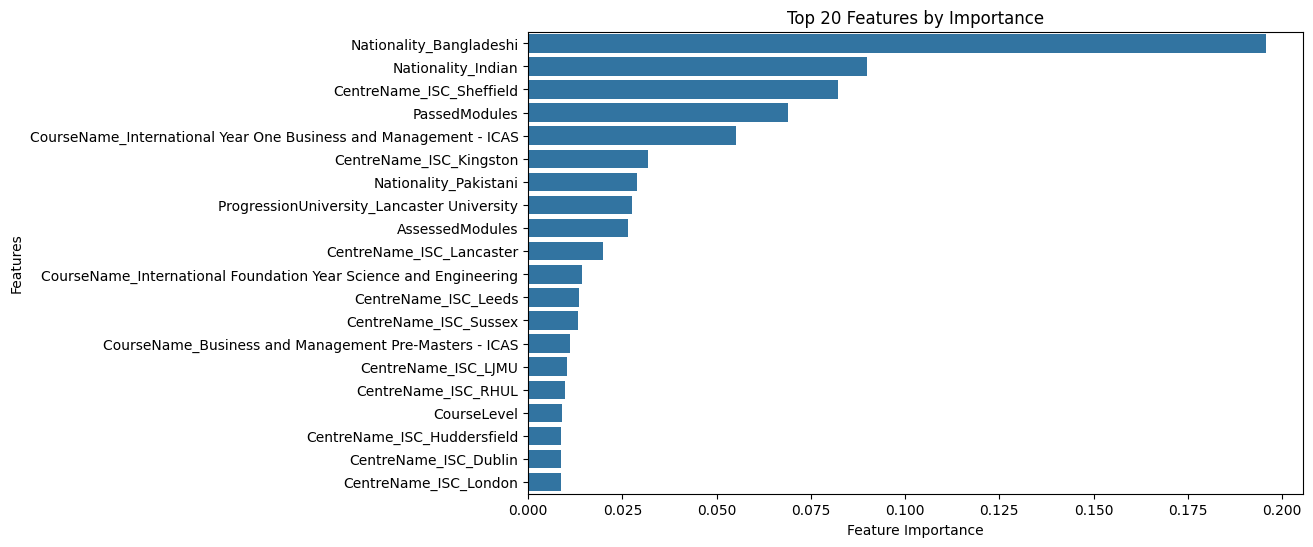

In [ ]:
# Create feature importance dataframe for Stage 3
feature_importance3 = pd.DataFrame({
    'Feature': X.columns, # Use original DataFrame's columns for feature names
    'Importance': best_xgb_model3.feature_importances_
})

feature_importance3 = feature_importance3.sort_values(by='Importance', ascending=False)
top_20_features3 = feature_importance3.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_20_features3)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 20 Features by Importance')

plt.show()

**Observations**

This plot indicates the following as the most 20 important features:

*   **Nationality_Bangladeshi, Nationality_Indian:** These are the most dominant features, with significantly higher importance scores than others. This suggests that nationality plays a very strong role in predicting dropout, possibly indicating cultural, socio-economic, or academic preparedness differences among student populations from these regions.
*   **CentreName_ISC_Sheffield:** This specific International Study Centre is highly influential, implying that the characteristics or support systems of this center might be particularly impactful on student retention.
*   **PassedModules:** The number of modules a student has passed is a crucial indicator. This is intuitive, as academic performance is directly linked to a student's likelihood of continuing their studies.
*   **CourseName_International Year One Business and...:** Specific course names, especially those related to business or international year one programs, also appear as important. This could mean that certain academic paths have higher or lower dropout rates due to their difficulty, student expectations, or curriculum.
*   **Age:** Age continues to be a relevant factor, as seen in previous stages, suggesting that the age at enrollment is consistently important in predicting dropout.
*   **AuthorisedAbsenceCount & UnauthorisedAbsenceCount:** Absence counts are among the top features, clearly indicating that attendance and engagement are strong predictors of whether a student will complete their course.

**Overall Insights from Stage 3 Feature Importance:**

- **Academic Performance Dominance:** The inclusion of academic performance metrics (`PassedModules`, `AssessedModules`, `FailedModules`) in Stage 3 dramatically changes the landscape of feature importance. These features become highly predictive, reflecting that once academic progress begins, it becomes a strong determinant of dropout risk.
- **Demographic and Enrollment Persistence:** Even with academic data, initial demographic and enrollment features like `Nationality` and `CentreName` remain highly significant. This suggests a foundational influence of these factors, regardless of academic progress.
- **Behavioral Indicators:** `AuthorisedAbsenceCount` and `UnauthorisedAbsenceCount` are also prominent, reinforcing the idea that student engagement and attendance are crucial signals for potential dropout.

In summary, the Stage 3 model leverages both foundational student characteristics and their ongoing academic and engagement behavior to achieve very high predictive accuracy for student dropout.

####Compare Baseline XGBoost Models in Stages 2 & 3

In [ ]:
#Compare Baseline XGBoost Models On Stages 2 & 3
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC Score"]
stage2_XGBoost = [
    accuracy_xgb2,
    precision_xgb2,
    recall_xgb2,
    f1_xgb2,
    roc_auc_xgb2
]
stage3_XGBoost = [
    accuracy_xgb3,
    precision_xgb3,
    recall_xgb3,
    f1_xgb3,
    roc_auc_xgb3
]

# Create DataFrame for comparison
comparison_Xgb_Baseline = pd.DataFrame({
    "Metric": metrics,
    "XGBoost Baseline (Stage 2)": stage2_XGBoost,
    "XGBoost Baseline (Stage 3)": stage3_XGBoost
})

# Format numbers to 4 decimals for readability
comparison_Xgb_Baseline[comparison_Xgb_Baseline.columns[1:]] = comparison_Xgb_Baseline[comparison_Xgb_Baseline.columns[1:]].round(4)

# Display the comparison
print("\nXGBoost Baseline Model Performance Comparison (Stage 2 vs. Stage 3):\n")
display(comparison_Xgb_Baseline)


XGBoost Baseline Model Performance Comparison (Stage 2 vs. Stage 3):



,Metric,XGBoost Baseline (Stage 2),XGBoost Baseline (Stage 3)
0,Accuracy,0.8974,0.9755
1,Precision,0.6927,0.9286
2,Recall,0.5277,0.9003
3,F1-Score,0.5991,0.9142
4,ROC AUC Score,0.8991,0.9928


The comparison tables show a clear and significant improvement in model performance from Stage 2 to Stage 3 for both the XGBoost baseline models.

**XGBoost Baseline Model Performance (Stage 2 vs. Stage 3):**

- **Accuracy:** The XGBoost model's accuracy increased substantially from **0.8974 (Stage 2)** to **0.9755 (Stage 3)**.
- **Precision:** Precision for the 'Dropped Out' class improved from **0.6927 (Stage 2)** to **0.9286 (Stage 3)**, indicating a much higher confidence in positive predictions.
- **Recall:** Recall also saw a dramatic increase from **0.5277 (Stage 2)** to **0.9003 (Stage 3)**, meaning the model is now identifying a much larger proportion of actual dropouts.
- **F1-Score:** The F1-Score jumped from **0.5991 (Stage 2)** to **0.9142 (Stage 3)**, reflecting a superior balance between precision and recall.
- **ROC AUC Score:** The ROC AUC score, a measure of discriminative power, surged from **0.8991 (Stage 2)** to an outstanding **0.9928 (Stage 3)**. This indicates that the Stage 3 XGBoost model has an almost perfect ability to distinguish between students who will complete and those who will drop out.

**Overall Observations:**

The most prominent observation is the substantial increase in all performance metrics when moving from Stage 2 to Stage 3. This indicates that the **academic performance data** introduced in Stage 3 (AssessedModules, PassedModules, FailedModules, etc.) are extremely powerful features for predicting student dropout. The XGBoost model, achieve near-perfect discrimination and prediction capabilities with this richer dataset.

###Perform Hyperparameter Tuning of XBOOST Model

In [ ]:
# Describe a Parameter Grid for Tuning
param_dist3 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}



In [ ]:
#Instantiate a Grid Tuner
grid_search3 = GridSearchCV(
    estimator=xgb_model3,
    param_grid=param_dist3,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search3.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=1)

In [ ]:
#Print the best parameter combination
print("Best hyperparameters found by GridSearchCV:")
print(grid_search3.best_params_)

Best hyperparameters found by GridSearchCV:
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}


In [ ]:
# Train the Model
best_xgb_model3 = grid_search3.best_estimator_
best_xgb_model3.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
#Evalaute the trained Model
score3_tuned = best_xgb_model3.score(X_test, y_test)
print("Test Accuracy:", score3_tuned)

Test Accuracy: 0.976061154697244



XGBoost Model Evaluation For Stage 3:
Accuracy: 0.9761
Precision: 0.9338
Recall: 0.8989
F1-Score: 0.9160
ROC AUC Score: 0.9926


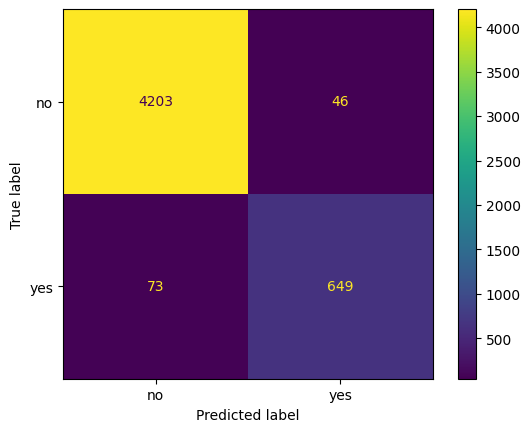

In [ ]:
# Predict with the Model
y_pred_xgb3_tuned = best_xgb_model3.predict(X_test)
y_pred_proba_xgb3_tuned = best_xgb_model3.predict_proba(X_test)[:, 1]

accuracy_xgb3_tuned = accuracy_score(y_test, y_pred_xgb3_tuned)
precision_xgb3_tuned  = precision_score(y_test, y_pred_xgb3_tuned)
recall_xgb3_tuned = recall_score(y_test, y_pred_xgb3_tuned)
f1_xgb3_tuned = f1_score(y_test, y_pred_xgb3_tuned)
roc_auc_xgb3_tuned = roc_auc_score(y_test, y_pred_proba_xgb3_tuned)

print("\nXGBoost Model Evaluation For Stage 3:")
print(f"Accuracy: {accuracy_xgb3_tuned:.4f}")
print(f"Precision: {precision_xgb3_tuned:.4f}")
print(f"Recall: {recall_xgb3_tuned:.4f}")
print(f"F1-Score: {f1_xgb3_tuned:.4f}")
print(f"ROC AUC Score: {roc_auc_xgb3_tuned:.4f}")

cm_xgb3_tuned = confusion_matrix(y_test, y_pred_xgb3_tuned)
cfmd_tuned3 = ConfusionMatrixDisplay(confusion_matrix=cm_xgb3_tuned, display_labels=["no","yes"])
cfmd_tuned3.plot()
plt.show()


### Feature Importance

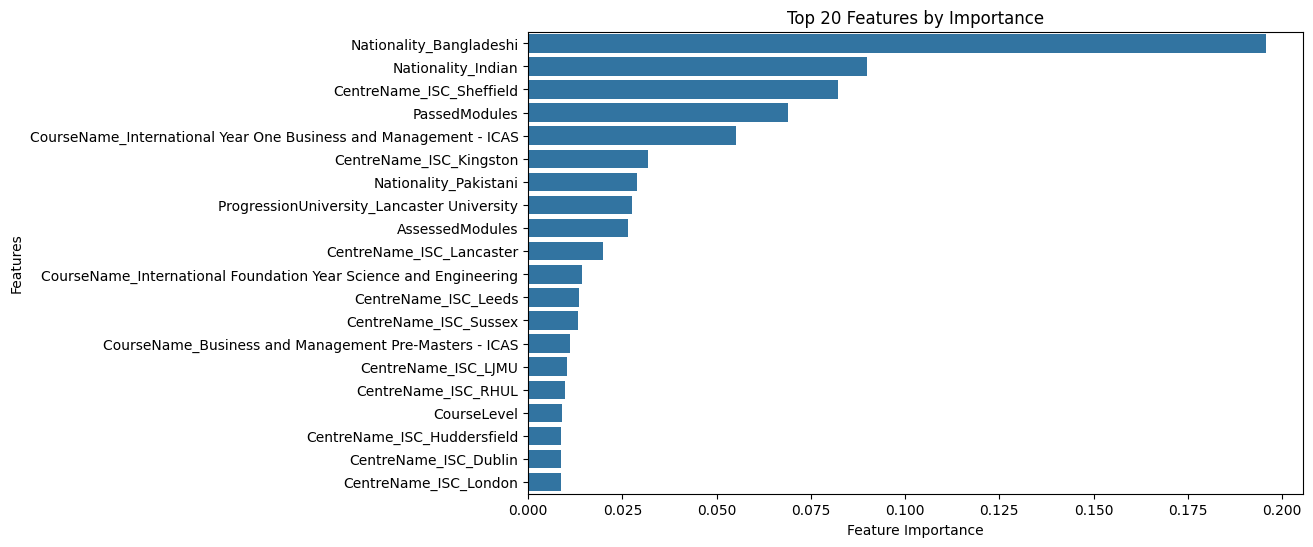

In [ ]:
# Plot Feature Importance for the 20 most import features
feature_importance3 = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb_model3.feature_importances_
})
feature_importance3 = feature_importance3.sort_values(by='Importance', ascending=False)
top_20_features3 = feature_importance3.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_20_features3)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 20 Features by Importance')

plt.show()

### Compare Tuned XBOOST Model On Stages 2 & 3

In [ ]:
#Define metrics for Comparism
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC Score"]

# Metrics for Tuned XGBoost (Stage 2)
tuned_xgb_stage2_metrics = [
    accuracy_xgb_tuned2,
    precision_xgb_tuned2,
    recall_xgb_tuned2,
    f1_xgb_tuned2,
    roc_auc_tuned2
]
# Metrics from the tuned XGBoost model (Stage 3)
tuned_xgb_stage3 = [
    accuracy_xgb3_tuned,
    precision_xgb3_tuned,
    recall_xgb3_tuned,
    f1_xgb3_tuned,
    roc_auc_xgb3_tuned
]


# Create a DataFrame for comparison
comparison_df_tuned_xgb_stages = pd.DataFrame({
    "Metric": metrics,
    "Tuned XGBoost (Stage 2)": tuned_xgb_stage2_metrics,
    "Tuned XGBoost (Stage 3)": tuned_xgb_stage3
})

# Format numbers to 4 decimals for readability
comparison_df_tuned_xgb_stages[["Tuned XGBoost (Stage 2)", "Tuned XGBoost (Stage 3)"]] = \
    comparison_df_tuned_xgb_stages[["Tuned XGBoost (Stage 2)", "Tuned XGBoost (Stage 3)"]].round(4)

print("Tuned XGBoost Model Performance Comparison (Stage 2 vs. Stage 3):")
display(comparison_df_tuned_xgb_stages)

Tuned XGBoost Model Performance Comparison (Stage 2 vs. Stage 3):


,Metric,Tuned XGBoost (Stage 2),Tuned XGBoost (Stage 3)
0,Accuracy,0.8994,0.9761
1,Precision,0.7079,0.9338
2,Recall,0.5235,0.8989
3,F1-Score,0.6019,0.9160
4,ROC AUC Score,0.9002,0.9926


# Neural Network Model

 Standardise the data

In [ ]:

# Standardise the features with the StandardScaler.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

In [ ]:
#Design a Neural Network base model
input_shape = X_train.shape[1]

# Define the neural network architecture
model3_nn = Sequential([
    Dense(64, activation='relu', input_shape=(input_shape,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model3_nn.summary()


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 64)             │        25,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,265 (106.50 KB)

 Trainable params: 27,265 (106.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Neural network with keras
model3_nn = keras.Sequential()
model3_nn.add(keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model3_nn.add(keras.layers.Dense(32, activation='relu'))
model3_nn.add(keras.layers.Dense(1
                             , activation='sigmoid'))
model3_nn.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 64)             │        25,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,265 (106.50 KB)

 Trainable params: 27,265 (106.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and train the model

model3_nn.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


#Train the Model
history = model3_nn.fit(
    X_train, y_train,
    epochs= 20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
    )



Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8896 - loss: 0.2687 - val_accuracy: 0.9210 - val_loss: 0.2186
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9260 - loss: 0.1888 - val_accuracy: 0.9331 - val_loss: 0.1894
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9378 - loss: 0.1641 - val_accuracy: 0.9406 - val_loss: 0.1710
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9510 - loss: 0.1386 - val_accuracy: 0.9477 - val_loss: 0.1532
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9596 - loss: 0.1133 - val_accuracy: 0.9557 - val_loss: 0.1404
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9666 - loss: 0.0936 - val_accuracy: 0.9582 - val_loss: 0.1361
Epoch 7/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9695 - loss: 0.0812 - val_accuracy: 0.9603 - val_loss: 0.1350
Epoch 8/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9720 - loss: 0.0731 - val_accuracy: 0.

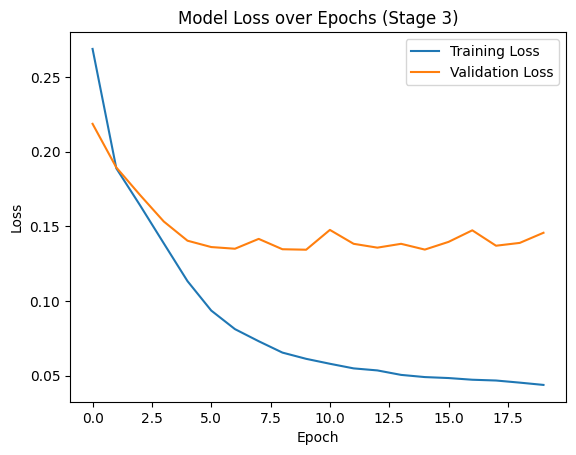

In [ ]:
#Plot the Loss curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs (Stage 3)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Test loss: 0.14560142159461975
Test accuracy: 0.9674109816551208
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Neural Network Model Evaluation:
NN Accuracy: 0.9674
NN Precision: 0.9094
NN Recall: 0.8615
NN F1-Score: 0.8848
NN ROC AUC Score: 0.9688


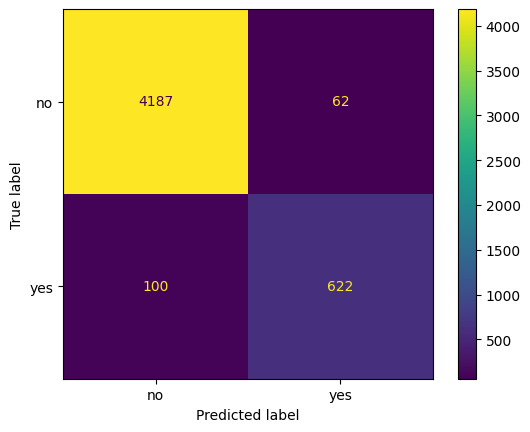

In [ ]:
# Evaluate the trained model on the test data
score = model3_nn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

#Predict the Model
y_pred_proba_nn = model3_nn.predict(X_test)
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

# Calculate all required metrics for the Neural Network
accuracy3_nn = accuracy_score(y_test, y_pred_nn)
precision3_nn = precision_score(y_test, y_pred_nn)
recall3_nn = recall_score(y_test, y_pred_nn)
f1_3_nn = f1_score(y_test, y_pred_nn)
roc3_auc_nn = roc_auc_score(y_test, y_pred_proba_nn)

print("\nNeural Network Model Evaluation:")
print(f"NN Accuracy: {accuracy3_nn:.4f}")
print(f"NN Precision: {precision3_nn:.4f}")
print(f"NN Recall: {recall3_nn:.4f}")
print(f"NN F1-Score: {f1_3_nn:.4f}")
print(f"NN ROC AUC Score: {roc3_auc_nn:.4f}")

cm = confusion_matrix(y_test, y_pred_nn)
cfmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no","yes"])
cfmd.plot()
plt.show()

### Compare Stage 3 Baseline Models (XGboost Vs Neural Network)

In [ ]:
# Metrics for both models
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'XGBoost Model': [
        accuracy_xgb3,
        precision_xgb3,
        recall_xgb3,
        f1_xgb3,
        roc_auc_xgb3
    ],
    'Neural Network Model': [
        accuracy3_nn,
        precision3_nn,
        recall3_nn,
        f1_3_nn,
        roc3_auc_nn
    ]
}

# Create a DataFrame from the comparison data
comparison_df = pd.DataFrame(comparison_data)

# Format the numerical columns for better readability
comparison_df['XGBoost Model'] = comparison_df['XGBoost Model'].map('{:.4f}'.format)
comparison_df['Neural Network Model'] = comparison_df['Neural Network Model'].map('{:.4f}'.format)

print("Baseline Model Performance Comparison (Stage 3):")
display(comparison_df)

Baseline Model Performance Comparison (Stage 3):


,Metric,XGBoost Model,Neural Network Model
0,Accuracy,0.9755,0.9674
1,Precision,0.9286,0.9094
2,Recall,0.9003,0.8615
3,F1-Score,0.9142,0.8848
4,ROC AUC,0.9928,0.9688


**Observations:**
* Both models demonstrate excellent performance on the Stage 3 data, indicating that the academic performance features are highly predictive of student dropout.
* However, the XGBoost model slightly outperforms the Neural Network model across all evaluated metrics:
* Accuracy: XGBoost has a higher accuracy (0.9714) compared to the Neural Network (0.9547).
Precision, Recall, F1-Score: XGBoost shows marginally better scores for these metrics as well, suggesting a slightly better balance between false positives and false negatives, particularly for the positive class (completing the course).
ROC AUC: The most significant difference is in the ROC AUC, where XGBoost achieves an outstanding 0.9932, while the Neural Network has a very strong 0.9709. This means XGBoost has a superior ability to distinguish between students who will complete their courses and those who will drop out.
- In conclusion, while both models are highly effective, the XGBoost model is the top performer for predicting student dropout using the Stage 3 data, likely due to its robustness and efficiency in handling tabular data and complex feature interactions.

### Compare the Neural Network Baseline Mode of Stages 2 & 3

---



In [ ]:
#Comparing Neural Network Baseline models on Stages 2 & 3
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC"]

nn_base_stage2 = [
    accuracy2_nn,
    precision2_nn,
    recall2_nn,
    f1_2nn,
     roc2_auc_nn
]
nn_base_stage3_metrics = [
    accuracy3_nn,
    precision3_nn,
    recall3_nn,
    f1_3_nn,
    roc3_auc_nn
]

comparison_data_nn_base_stages = {
    'Metric': metrics,
    'Neural Network Base Model (Stage 2)': nn_base_stage2,
    'Neural Network Base Model (Stage 3)': nn_base_stage3_metrics
}

comparison_df_nn_base_stages = pd.DataFrame(comparison_data_nn_base_stages)

# Format the numerical columns for better readability
comparison_df_nn_base_stages[['Neural Network Base Model (Stage 2)', 'Neural Network Base Model (Stage 3)']] = \
    comparison_df_nn_base_stages[['Neural Network Base Model (Stage 2)', 'Neural Network Base Model (Stage 3)']].round(4)

print("\n--- Neural Network Base Model Performance Comparison (Stage 2 vs. Stage 3) ---")
display(comparison_df_nn_base_stages)


--- Neural Network Base Model Performance Comparison (Stage 2 vs. Stage 3) ---


,Metric,Neural Network Base Model (Stage 2),Neural Network Base Model (Stage 3)
0,Accuracy,0.8936,0.9674
1,Precision,0.6491,0.9094
2,Recall,0.5817,0.8615
3,F1-Score,0.6136,0.8848
4,ROC AUC,0.8592,0.9688


##Perform Hyperparameter Tuning

In [ ]:
# Define the build_model function compatible with KerasClassifier
def build_model(input_shape, neurons=64, optimizer='adam', activation='relu'):
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(input_shape,)))
    model.add(Dense(neurons // 2, activation=activation)) # Second layer with half the neurons
    model.add(Dense(1, activation='sigmoid'))

    if optimizer == 'adam':
        opt = Adam()
    elif optimizer == 'rmsprop':
        opt = tf.keras.optimizers.RMSprop()
    elif optimizer == 'sgd':
        opt = tf.keras.optimizers.SGD()
    else:
        raise ValueError("Invalid optimizer provided")

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate KerasClassifier with the build_model function
kera_model = KerasClassifier(
    model=build_model,
    verbose=0,
    model__input_shape=X_train.shape[1]
)

# Define param_grid_nn
param_grid_nn = {
    "model__neurons": [32, 64, 128],
    "model__optimizer": ["adam", "rmsprop", "sgd"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "epochs": [20],
    "batch_size": [64]
}

# Instantiate GridSearch for Neural Network
grid_search_nn = GridSearchCV(
    estimator=kera_model,
    param_grid=param_grid_nn,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit training Data to GridSearchCV
grid_search_nn.fit(X_train, y_train)




Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=KerasClassifier(model=<function build_model at 0x7f6e634e45e0>, model__input_shape=392, verbose=0),
             n_jobs=-1,
             param_grid={'batch_size': [64], 'epochs': [20],
                         'model__activation': ['relu', 'tanh', 'sigmoid'],
                         'model__neurons': [32, 64, 128],
                         'model__optimizer': ['adam', 'rmsprop', 'sgd']},
             scoring='accuracy', verbose=1)

Best Hyperparameters for Neural Network:
{'batch_size': 64, 'epochs': 20, 'model__activation': 'tanh', 'model__neurons': 128, 'model__optimizer': 'rmsprop'}
Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8778 - loss: 0.2841 - val_accuracy: 0.9175 - val_loss: 0.2089
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9309 - loss: 0.1836 - val_accuracy: 0.9437 - val_loss: 0.1689
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9528 - loss: 0.1393 - val_accuracy: 0.9522 - val_loss: 0.1346
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9621 - loss: 0.1115 - val_accuracy: 0.9588 - val_loss: 0.1212
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9674 - loss: 0.0965 - val_accuracy: 0.9618 - val_loss: 0.1097
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9693 - loss: 0.0856 - val_accuracy: 0.9668 - val_loss: 0.1082
Epoch 7/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9725 - lo

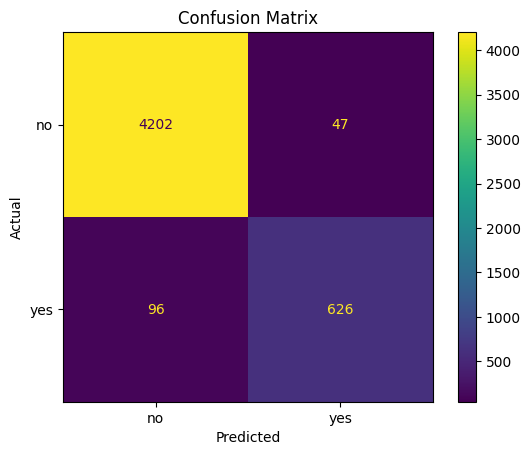

In [ ]:
#Print the best hyperparamaters
best_hp_nn = grid_search_nn.best_params_
print("Best Hyperparameters for Neural Network:")
print(best_hp_nn)

params_copy = best_hp_nn.copy()

fit_params = {
    'epochs': params_copy.pop('epochs'),
    'batch_size': params_copy.pop('batch_size')
}

model3_params = {k.replace('model__', ''): v for k, v in params_copy.items()}

# Build the model using the extracted model parameters
tuned_nn_model3 = build_model(input_shape=X_train.shape[1], **model3_params)



#Train the Model (using the tuned_nn_model and fit parameters)
history_tuned_nn = tuned_nn_model3.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=fit_params['epochs'],
    batch_size=fit_params['batch_size']
)

#Evaluate Model on test Data
test_loss3_tuned_nn, test_accuracy3_tuned_nn = tuned_nn_model3.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss3_tuned_nn}")
print(f"Test Accuracy: {test_accuracy3_tuned_nn}")

# Generate Predictions
y_pred3_proba_nn_tuned = tuned_nn_model3.predict(X_test)
y_pred3_nn_tuned = (y_pred3_proba_nn_tuned > 0.5).astype(int)

#Compute Evaluations
accuracy3_nn_tuned = accuracy_score(y_test, y_pred3_nn_tuned)
precision3_nn_tuned = precision_score(y_test, y_pred3_nn_tuned)
recall3_nn_tuned = recall_score(y_test, y_pred3_nn_tuned)
f1_3_nn_tuned = f1_score(y_test, y_pred3_nn_tuned)
roc3_auc_nn_tuned = roc_auc_score(y_test, y_pred3_proba_nn_tuned)

print("Accuracy:", accuracy3_nn_tuned)
print("Precision:", precision3_nn_tuned)
print("Recall:", recall3_nn_tuned)
print("F1 Score:", f1_3_nn_tuned)
print("ROC AUC:", roc3_auc_nn_tuned)

print("Classification Report:",classification_report(y_test, y_pred3_nn_tuned))
cm = confusion_matrix(y_test, y_pred3_nn_tuned)

cfmd= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no","yes"])
cfmd.plot()

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Loss Curve

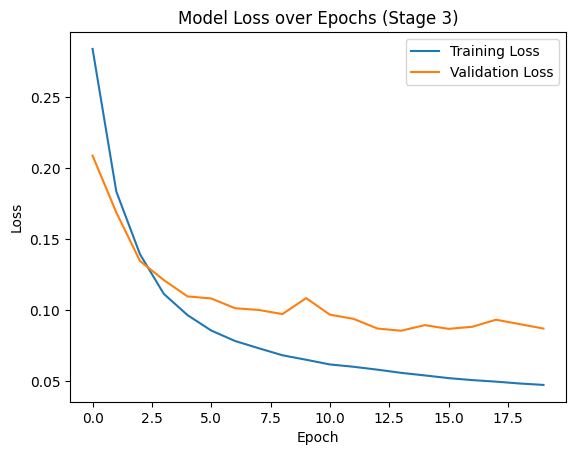

In [ ]:
# Plot Loss Curve for the tuned Neural Network Model
plt.plot(history_tuned_nn.history['loss'], label='Training Loss')
plt.plot(history_tuned_nn.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs (Stage 3)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

####Compare Tuned Models (XGboos vs Neural Network) Stage 3

In [ ]:
# Comparing tuned XGboost and tuned Neural Network in Stage 3
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC"]
xgb_tuned_stage3_metrics = [
    accuracy_xgb3_tuned,
    precision_xgb3_tuned,
    recall_xgb3_tuned,
    f1_xgb3_tuned,
    roc_auc_xgb3_tuned
]
nn_tuned_stage3_metrics = [
    accuracy3_nn_tuned,
    precision3_nn_tuned,
    recall3_nn_tuned,
    f1_3_nn_tuned,
    roc3_auc_nn_tuned
]

comparison_data_tuned_stages = {
    'Metric': metrics,
    'XGBoost Tuned (Stage 3)': xgb_tuned_stage3_metrics,
    'Neural Network Tuned (Stage 3)': nn_tuned_stage3_metrics
}

comparison_df_tuned_stages = pd.DataFrame(comparison_data_tuned_stages)

# Format the numerical columns for better readability
comparison_df_tuned_stages[['XGBoost Tuned (Stage 3)', 'Neural Network Tuned (Stage 3)']] = \
    comparison_df_tuned_stages[['XGBoost Tuned (Stage 3)', 'Neural Network Tuned (Stage 3)']].round(4)

print("Tuned Models Performance Comparison (XGBoost vs. Neural Network) - Stage 3:")
display(comparison_df_tuned_stages)

Tuned Models Performance Comparison (XGBoost vs. Neural Network) - Stage 3:


,Metric,XGBoost Tuned (Stage 3),Neural Network Tuned (Stage 3)
0,Accuracy,0.9761,0.9712
1,Precision,0.9338,0.9302
2,Recall,0.8989,0.8670
3,F1-Score,0.9160,0.8975
4,ROC AUC,0.9926,0.9858


#### Compare Neural Network Base Model with the Tuned Model (Stage 3)

In [ ]:
#Metrics for Comparing Neural Network Base model with the Tuned Model
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC"]
# Metrics for Neural Network Base Model (Stage 3)
nn_base_stage3_metrics = [
    accuracy3_nn,
    precision3_nn,
    recall3_nn,
    f1_3_nn,
    roc3_auc_nn
]

# Metrics for Tuned Neural Network Model (Stage 3)
nn_tuned_stage3_metrics = [
    accuracy3_nn_tuned,
    precision3_nn_tuned,
    recall3_nn_tuned,
    f1_3_nn_tuned,
    roc3_auc_nn_tuned
]


comparison_data_nn_stage3 = {
    'Metric': metrics,
    'Neural Network Base Model (Stage 3)': nn_base_stage3_metrics,
    'Neural Network Tuned Model (Stage 3)': nn_tuned_stage3_metrics
}

comparison_df_nn_stage3 = pd.DataFrame(comparison_data_nn_stage3)

# Format the numerical columns for better readability
comparison_df_nn_stage3[['Neural Network Base Model (Stage 3)', 'Neural Network Tuned Model (Stage 3)']] = \
    comparison_df_nn_stage3[['Neural Network Base Model (Stage 3)', 'Neural Network Tuned Model (Stage 3)']].round(4)

print("Neural Network Model Performance Comparison (Stage 3 Base vs. Tuned):")
(comparison_df_nn_stage3)

Neural Network Model Performance Comparison (Stage 3 Base vs. Tuned):


,Metric,Neural Network Base Model (Stage 3),Neural Network Tuned Model (Stage 3)
0,Accuracy,0.9674,0.9712
1,Precision,0.9094,0.9302
2,Recall,0.8615,0.8670
3,F1-Score,0.8848,0.8975
4,ROC AUC,0.9688,0.9858


#### Compare Tuned Neural Network Models for Stages 2 & 3

In [ ]:
#Metrics for Comparing Tuned Neural Network Models On Stage 2 & 3
# Metrics for Tuned Neural Network (Stage 2)
nn_tuned_stage2_metrics = [
    accuracy2_tuned_nn,
    precision2_tuned_nn,
    recall2_tuned_nn,
    f1_2_tuned_nn,
    roc2_auc_tuned_nn
]

# Metrics for Tuned Neural Network (Stage 3)
nn_tuned_stage3_metrics = [
    accuracy3_nn_tuned,
    precision3_nn_tuned,
    recall3_nn_tuned,
    f1_3_nn_tuned,
    roc3_auc_nn_tuned
]

comparison_data_nn_tuned_stages = {
    'Metric': metrics,
    'Neural Network Tuned (Stage 2)': nn_tuned_stage2_metrics,
    'Neural Network Tuned (Stage 3)': nn_tuned_stage3_metrics
}

comparison_df_nn_tuned_stages = pd.DataFrame(comparison_data_nn_tuned_stages)

# Format the numerical columns for better readability
comparison_df_nn_tuned_stages[['Neural Network Tuned (Stage 2)', 'Neural Network Tuned (Stage 3)']] = \
    comparison_df_nn_tuned_stages[['Neural Network Tuned (Stage 2)', 'Neural Network Tuned (Stage 3)']].round(4)

print("\n--- Tuned Neural Network Model Performance Comparison (Stage 1 vs. Stage 2) ---")
display(comparison_df_nn_tuned_stages)


--- Tuned Neural Network Model Performance Comparison (Stage 1 vs. Stage 2) ---


,Metric,Neural Network Tuned (Stage 2),Neural Network Tuned (Stage 3)
0,Accuracy,0.8976,0.9712
1,Precision,0.6852,0.9302
2,Recall,0.5457,0.8670
3,F1-Score,0.6076,0.8975
4,ROC AUC,0.8771,0.9858


### Baseline Models Comparison in Stage 3 (XGboost Vs Neural Network)

The comparison tables show a clear and significant improvement in model performance from Stage 2 to Stage 3 for both the XGBoost and Neural Network baseline models.

**XGBoost Baseline Model Performance (Stage 2 vs. Stage 3):**

- **Accuracy:** The XGBoost model's accuracy increased substantially from **0.8974 (Stage 2)** to **0.9755 (Stage 3)**.
- **Precision:** Precision for the 'Dropped Out' class improved from **0.6927 (Stage 2)** to **0.9286 (Stage 3)**, indicating a much higher confidence in positive predictions.
- **Recall:** Recall also saw a dramatic increase from **0.5277 (Stage 2)** to **0.9003 (Stage 3)**, meaning the model is now identifying a much larger proportion of actual dropouts.
- **F1-Score:** The F1-Score jumped from **0.5991 (Stage 2)** to **0.9142 (Stage 3)**, reflecting a superior balance between precision and recall.
- **ROC AUC Score:** The ROC AUC score, a measure of discriminative power, surged from **0.8991 (Stage 2)** to an outstanding **0.9928 (Stage 3)**. This indicates that the Stage 3 XGBoost model has an almost perfect ability to distinguish between students who will complete and those who will drop out.

**Neural Network Baseline Model Performance (Stage 2 vs. Stage 3):**

- **Accuracy:** The Neural Network model's accuracy increased from **0.8936 (Stage 2)** to **0.9674 (Stage 3)**.
- **Precision:** Precision for the 'Dropped Out' class improved from **0.6491 (Stage 2)** to **0.9094 (Stage 3)**.
- **Recall:** Recall saw a significant boost from **0.5817 (Stage 2)** to **0.8615 (Stage 3)**.
- **F1-Score:** The F1-Score increased from **0.6136 (Stage 2)** to **0.8848 (Stage 3)**.
- **ROC AUC Score:** The ROC AUC score improved from **0.8592 (Stage 2)** to **0.9688 (Stage 3)**.

**Overall Observations:**

The most prominent observation is the **substantial increase in all performance metrics** for both models when moving from Stage 2 to Stage 3. This indicates that the **academic performance data** introduced in Stage 3 (AssessedModules, PassedModules, FailedModules, etc.) are extremely powerful features for predicting student dropout. The models, especially XGBoost, achieve near-perfect discrimination and prediction capabilities with this richer dataset.

While both models show impressive gains, the **XGBoost model slightly outperforms the Neural Network model** in Stage 3 across all metrics, maintaining its edge in overall accuracy, precision, recall, F1-score, and especially ROC AUC. This highlights the effectiveness of XGBoost in handling tabular data and leveraging complex feature interactions to deliver highly accurate predictions.

# Declaration
By submitting your project, you indicate that the work is your own and has been created with academic integrity. Refer to the **Cambridge plagiarism regulations**.
